# **The Baltic Sentinel: Evaluating Estonia’s Energy Resilience**

## **1. Introduction** 


In early 2026, Estonia's electricity system faced a severe stress event driven by extreme cold, weak wind generation, and major production outages ([ERR News](https://news.err.ee/1609927241/january-electricity-prices-highest-estonia-has-seen-in-years); [ERR News](https://news.err.ee/1609930625/cold-weather-driving-up-price-of-electricity-putting-production-capacity-to-the-test); [Elenger](https://elenger.ee/en/power-market-overview-q1-2026/)). This crisis pushed resilience margins to their limits, triggering record-high prices that peaked at 505.06 €/MWh in January and escalated to 655.48 €/MWh by February ([Konkurentsiamet](https://www.konkurentsiamet.ee/sites/default/files/documents/2026-04/Energiaturgude%20%C3%BClevaade%20veebruar%202026.pdf)).

January 2026 was exceptional because multiple stressors aligned perfectly. Decades-low temperatures across the Baltics and Finland coincided with record demand, weak wind, and outages, creating an ideal real-world case study ([Elenger](https://elenger.ee/en/power-market-overview-q1-2026/); [Konkurentsiamet](https://www.konkurentsiamet.ee/sites/default/files/documents/2026-04/Energiaturgude%20%C3%BClevaade%20veebruar%202026.pdf)). At a strategic level, Estonia's energy transition is moving away from legacy fossil generation toward renewables and modernised infrastructure. The tension between preserving grid reliability and accelerating this transition makes the 2026 crisis especially relevant for evaluating security of supply.

This project analyses that episode as a resilience problem rather than solely a pricing event. The key issue is not just why prices became so high, but what the event reveals about Estonia's ability to maintain a secure electricity supply under disruption. Estonia's system has historically depended on a combination of domestic generation, cross-border imports, and a growing share of renewables, meaning that its stability depends on both internal production and regional interconnection.

A central motivation for this project is the public debate around whether more wind capacity could have changed the outcome. In February 2026, Utilitas Wind published a modelled scenario arguing that the Liivi Bay offshore project could have halved January prices and saved society €75 million, framing wind capacity as a critical resilience measure rather than just a decarbonisation tool ([Ärileht / Delfi](https://arileht.delfi.ee/artikkel/120436765/utilitas-windi-juht-tuulepargid-voinuks-jaanuari-elektrihinna-pooleks-luua-ja-saasta-kumneid-miljoneid)).

**Our project therefore asks two linked questions:** 
* **1) How exposed was Estonia's power system during the January 2026 crisis if imports were unavailable?**
* **2) Could planned wind farm expansions have materially improved resilience during those critical hours?**

These questions matter because resilience is determined by system performance in the worst hours, not by average performance in normal conditions.

To answer this, the project combines historical analysis, forecasting, and counterfactual simulation. On the supply side, a spatio-temporal graph neural network is used to model electricity production under different grid states and wind scenarios. On the demand side, a separate forecasting framework estimates hourly consumption and its uncertainty under January 2026 conditions, after which supply and demand are compared under baseline, isolation, and wind-expansion scenarios.

This makes the project more than a forecasting exercise. By combining public reporting, industry claims, and scenario modelling, the project evaluates whether new wind investments would only lower emissions and average prices in normal times, or whether they could also strengthen security of supply during crisis conditions ([Ärileht / Delfi](https://arileht.delfi.ee/artikkel/120436765/utilitas-windi-juht-tuulepargid-voinuks-jaanuari-elektrihinna-pooleks-luua-ja-saasta-kumneid-miljoneid); [European Commission](https://reforms-investments.ec.europa.eu/recovery-and-resilience-facility-1/country-pages/estonias-recovery-and-resilience-plan_en)).

In [16]:
import subprocess, sys

_pkgs = [
    "pandas", "numpy", "matplotlib", "seaborn",
    "geopandas", "geodatasets",
    "requests", "graphviz",
]


for _pkg in _pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", _pkg], check=False)

In [ ]:
# Standard Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz
import os


# Note: Custom helper functions and modular scripts (STGNN, PowerScaler, etc.) 
# are hosted in the sandra359/advanced_ba repository.
import sys
import os

# Plotting configuration
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Standard Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.ticker as ticker


# Note: Custom helper functions and modular scripts (STGNN, PowerScaler, etc.) 
# are hosted in the sandra359/advanced_ba repository.
import sys, os
import helper_functions_GNN as hf

# Plotting configuration
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# !!! Define the style for all plots in the notebook

## **2. Data**

We structure our analysis in a way, where the electricity system is split into two main parts: demand and supply. This makes it easier to model each side separately, while still allowing us to bring them together later when assessing overall grid resilience.
On the demand side, we use historical electricity consumption and weather data to estimate how demand in January might vary. On the supply side, we look at production levels, wind capacity, cross-border flows, and market data to assess whether the system can meet the demand under different scenarios, including potential outages. This setup is useful because resilience isn’t just about how much electricity people need, but also depends on whether the system can reliably produce or import enough power for when conditions are uncertain.

---

### **2.1 Data Sources**

The project combines several data sources:

- **Grid Operations (Elering):**  
  Hourly electricity production, consumption, and cross-border flow data are used to represent the physical operation of the Estonian electricity system.

- **Market Pricing (Nord Pool):**  
  Day-ahead clearing prices for the Estonian, Finnish, and Latvian bidding zones are included to capture market conditions and regional price differences.

- **Weather Data (Open-Meteo API):**  
  Historical temperature and wind speed data are used as external drivers. Temperature is especially relevant for demand modelling, while wind speed is relevant for modelling renewable production potential.

Together, these sources allow us to model both the demand pressure on the system and the available supply capacity under different assumptions.

---

## **3. Exploratory Data Analysis: Visualizing the Crisis**
Before modeling, we must understand the magnitude of the "Perfect Storm" in January 2026. Here, we visualize the temperature-demand trap, the EstLink failure cliff, and flow divergence.

The plot below shows monthly average energy flows and production in Estonia from 2019 to 2026.

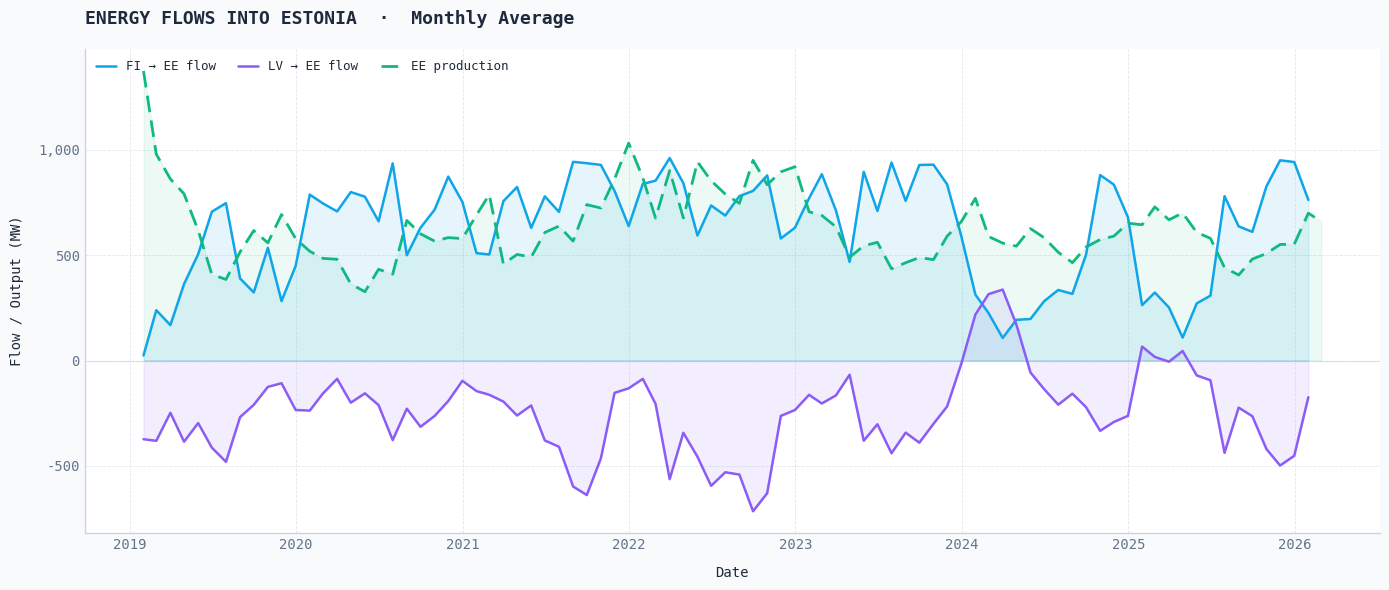

In [5]:
# How much import we have right now
df_electricity = pd.read_csv('data/elering_daily.csv')
df_electricity['timestamp'] = pd.to_datetime(df_electricity['timestamp'])
df_electricity.index = df_electricity['timestamp']
df_electricity.drop(columns=['timestamp'], inplace=True)

fi_to_ee = (-df_electricity["flow_('ee', 'fi')"]).resample('ME').mean()
lv_to_ee = (-df_electricity["flow_('ee', 'lv')"]).resample('ME').mean()
ee_prod   = df_electricity["system_production"].resample('ME').mean()

# --- Colors ---
C_FI   = "#0ea5e9"   # sky blue  — Finland
C_LV   = "#8b5cf6"   # violet    — Latvia
C_PROD = "#10b981"   # emerald   — EE production
TEXT   = "#1e293b"
GRID   = "#e2e8f0"
SPINE  = "#cbd5e1"

plt.rcParams.update({
    "font.family": "monospace",
    "axes.facecolor": "#ffffff",
    "figure.facecolor": "#f8fafc",
    "text.color": TEXT,
    "axes.labelcolor": TEXT,
    "xtick.color": "#64748b",
    "ytick.color": "#64748b",
    "axes.edgecolor": SPINE,
    "grid.color": GRID,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "legend.framealpha": 0.0,
})

fig, ax = plt.subplots(figsize=(14, 6))

# Filled areas
ax.fill_between(fi_to_ee.index, fi_to_ee, alpha=0.10, color=C_FI)
ax.fill_between(lv_to_ee.index, lv_to_ee, alpha=0.10, color=C_LV)
ax.fill_between(ee_prod.index,  ee_prod,  alpha=0.08, color=C_PROD)

# Lines
ax.plot(fi_to_ee.index, fi_to_ee, color=C_FI,   lw=1.8, label="FI → EE flow")
ax.plot(lv_to_ee.index, lv_to_ee, color=C_LV,   lw=1.8, label="LV → EE flow")
ax.plot(ee_prod.index,  ee_prod,  color=C_PROD,  lw=2.0, label="EE production",
        linestyle="--", dashes=(6, 3))

# Zero reference line
ax.axhline(0, color=SPINE, lw=0.8, zorder=0)

# Grid & spines
ax.grid(True, axis='y', zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(SPINE)
ax.spines["bottom"].set_color(SPINE)

# Labels & title
ax.set_xlabel("Date", labelpad=10, fontsize=10)
ax.set_ylabel("Flow / Output (MW)", labelpad=10, fontsize=10)
ax.set_title(
    "ENERGY FLOWS INTO ESTONIA  ·  Monthly Average",
    fontsize=13, fontweight="bold", color=TEXT,
    loc="left", pad=18
)

# X-axis
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))

# Y-axis
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

ax.legend(loc="upper left", fontsize=9, ncol=3, columnspacing=1.8, handlelength=1.6)

plt.tight_layout()
plt.savefig("energy_flows_ee.png", dpi=180, bbox_inches="tight", facecolor="#f8fafc")
plt.show()

**FI → EE (blue)** — Flow from Finland to Estonia stays broadly positive
throughout the period, hovering between 500–950 MW, which means Estonia
is consistently a net importer from Finland. A notable dip is observable around
2024, likely tied to the Baltic states' disconnection from the Russian
BRELL grid on February 8, 2025
([ERR News](https://news.err.ee/1609367879/baltics-to-leave-brell-electricity-grid-at-start-of-february-2025);
[Wikipedia](https://en.wikipedia.org/wiki/Baltic_states_synchronization_with_CESA)).

**EE production (green)** — Estonia's domestic output starts high around
1300 MW in 2019 and falls sharply through 2021–2022, eventually settling
in the 500–900 MW range. The decline closely follows the gradual phase-out
of oil shale power plants.

**LV → EE (purple)** — The Latvia–Estonia flow tells the opposite story:
it stays negative until around 2024, meaning Estonia was consistently
exporting to Latvia over that period. From 2024 onward the direction
reverses, with Estonia becoming a net importer, most likely a
consequence of the February 2025 synchronization with the Continental
European grid.

The clearest takeaway is the structural shift around 2024–2025, where
both interconnectors change character within a short window, pointing to
a single underlying cause rather than coincidence.

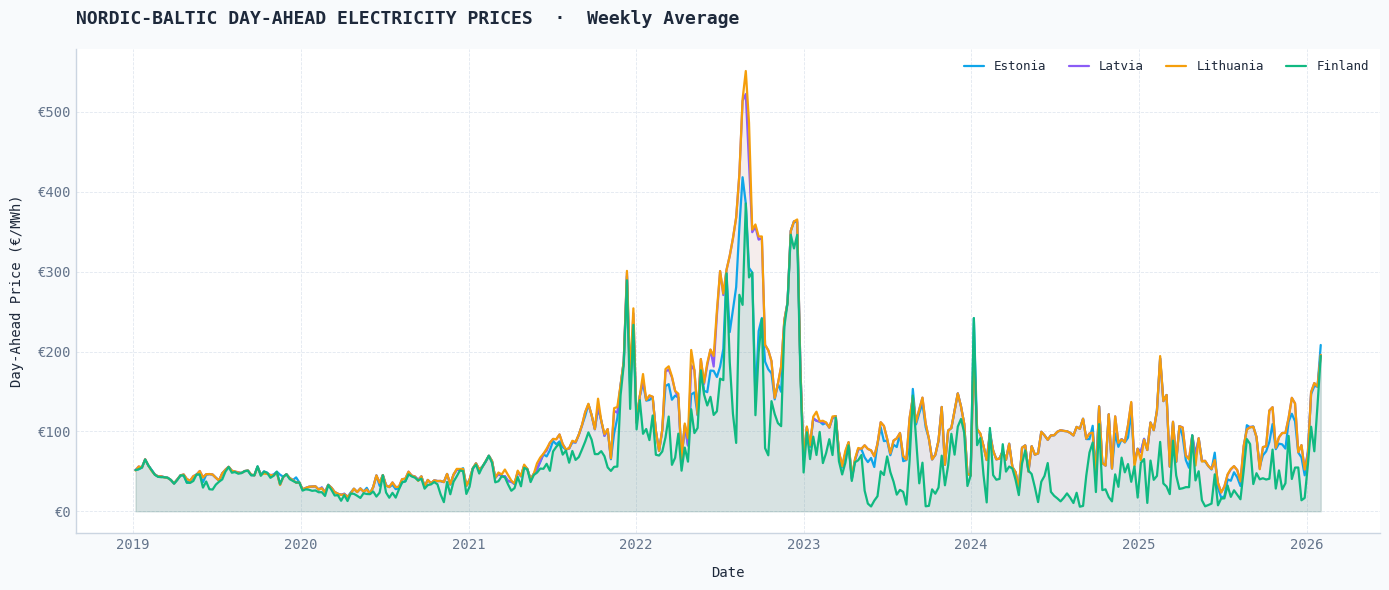

In [6]:
df_prices = hf.fetch_all(hf.get_nps_prices, "2019-01-01T23:00:00.000Z", "2026-01-31T22:59:59.999Z")

COLORS = {
    "ee": "#0ea5e9",   # sky blue
    "lv": "#8b5cf6",   # violet
    "lt": "#f59e0b",   # amber
    "fi": "#10b981",   # emerald
}

LABELS = {"ee": "Estonia", "lv": "Latvia", "lt": "Lithuania", "fi": "Finland"}

TEXT  = "#1e293b"
GRID  = "#e2e8f0"
SPINE = "#cbd5e1"

plt.rcParams.update({
    "font.family": "monospace",
    "axes.facecolor": "#ffffff",
    "figure.facecolor": "#f8fafc",
    "text.color": TEXT,
    "axes.labelcolor": TEXT,
    "xtick.color": "#64748b",
    "ytick.color": "#64748b",
    "axes.edgecolor": SPINE,
    "grid.color": GRID,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "legend.framealpha": 0.0,
})

# --- Resample to weekly to reduce noise ---
df_weekly = df_prices[list(COLORS.keys())].resample('W').mean()

fig, ax = plt.subplots(figsize=(14, 6))

for col, color in COLORS.items():
    ax.fill_between(df_weekly.index, df_weekly[col], alpha=0.07, color=color)
    ax.plot(df_weekly.index, df_weekly[col], color=color, lw=1.6, label=LABELS[col])

# Grid & spines
ax.grid(True, axis='y', zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(SPINE)
ax.spines["bottom"].set_color(SPINE)

# Labels & title
ax.set_xlabel("Date", labelpad=10, fontsize=10)
ax.set_ylabel("Day-Ahead Price (€/MWh)", labelpad=10, fontsize=10)
ax.set_title(
    "NORDIC-BALTIC DAY-AHEAD ELECTRICITY PRICES  ·  Weekly Average",
    fontsize=13, fontweight="bold", color=TEXT, loc="left", pad=18
)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))

ax.legend(loc="upper right", fontsize=9, ncol=4, columnspacing=1.8, handlelength=1.6)

plt.tight_layout()
plt.show()

**Nordic-Baltic day-ahead prices (2019–2026)**

From 2019 through mid-2021, prices across all four bidding zones were
remarkably stable and tightly coupled, hovering around €40–60/MWh.
Estonia, Latvia, Lithuania, and Finland tracked each other almost
perfectly during this period, suggesting uncongested interconnectors and
a well-integrated regional market.

The energy crisis of 2021–2023 broke that calm dramatically. Prices
surged from late 2021 onward, peaking sharply around mid-2022 with
Lithuania briefly touching €550/MWh. The Baltic states (EE, LV, LT)
moved largely in lockstep throughout the spike, while Finland diverged
more noticeably, as its access to Nordic hydro and nuclear capacity
offered some insulation, producing the green filled area that visibly
separates from the Baltics during the worst months.

After the crisis peak, prices collapsed back toward pre-crisis levels by
late 2023, though with considerably more volatility than before.
Finland in particular shows frequent sharp dips toward €0/MWh from 2023
onward, consistent with surplus renewable generation pushing spot prices
negative on windy or hydro-rich days, a pattern largely absent in the
Baltic states.

From 2024 onward, a modest upward drift is visible across all zones,
with Estonia spiking to around €200/MWh in early 2026. The divergence
between Finland and the Baltics also becomes more pronounced in this
period, likely reflecting the structural market changes following the
Baltic states' synchronization with the Continental European grid in
February 2025.

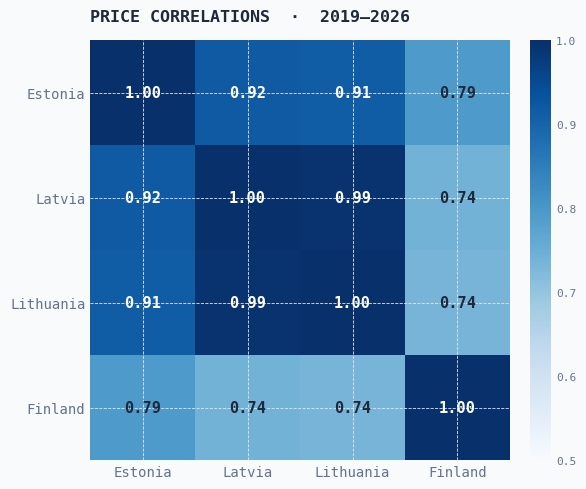

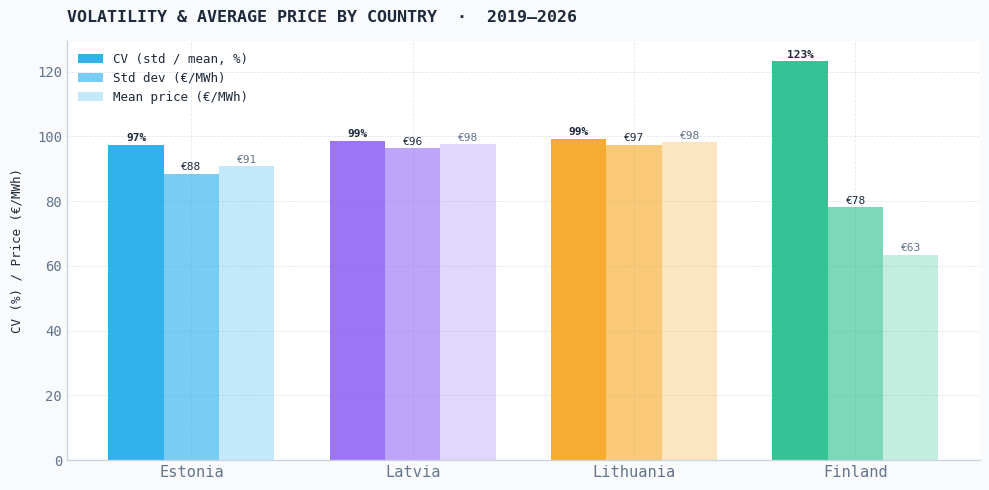

In [10]:
COLORS = {
    "ee": "#0ea5e9",
    "lv": "#8b5cf6",
    "lt": "#f59e0b",
    "fi": "#10b981",
}
LABELS = {"ee": "Estonia", "lv": "Latvia", "lt": "Lithuania", "fi": "Finland"}
COLS = list(COLORS.keys())

TEXT  = "#1e293b"
GRID  = "#e2e8f0"
SPINE = "#cbd5e1"

BASE_STYLE = {
    "font.family": "monospace",
    "axes.facecolor": "#ffffff",
    "figure.facecolor": "#f8fafc",
    "text.color": TEXT,
    "axes.labelcolor": TEXT,
    "xtick.color": "#64748b",
    "ytick.color": "#64748b",
    "axes.edgecolor": SPINE,
    "grid.color": GRID,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "legend.framealpha": 0.0,
}
plt.rcParams.update(BASE_STYLE)

corr = df_prices[COLS].corr()
labels = [LABELS[c] for c in COLS]

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(corr.values, cmap="Blues", vmin=0.5, vmax=1.0)

# Cell values
for i in range(len(COLS)):
    for j in range(len(COLS)):
        val = corr.values[i, j]
        text_color = "white" if val > 0.85 else TEXT
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=11, color=text_color, fontweight="bold")

ax.set_xticks(range(len(COLS)))
ax.set_yticks(range(len(COLS)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_yticklabels(labels, fontsize=10)
ax.tick_params(length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=8, colors="#64748b")
cbar.outline.set_visible(False)

ax.set_title("PRICE CORRELATIONS  ·  2019–2026",
             fontsize=12, fontweight="bold", color=TEXT, loc="left", pad=14)

plt.tight_layout()
plt.show()


COLORS = {
    "ee": "#0ea5e9",
    "lv": "#8b5cf6",
    "lt": "#f59e0b",
    "fi": "#10b981",
}
LABELS = {"ee": "Estonia", "lv": "Latvia", "lt": "Lithuania", "fi": "Finland"}
COLS = list(COLORS.keys())

TEXT  = "#1e293b"
GRID  = "#e2e8f0"
SPINE = "#cbd5e1"

plt.rcParams.update({
    "font.family": "monospace",
    "axes.facecolor": "#ffffff",
    "figure.facecolor": "#f8fafc",
    "text.color": TEXT,
    "axes.labelcolor": TEXT,
    "xtick.color": "#64748b",
    "ytick.color": "#64748b",
    "axes.edgecolor": SPINE,
    "grid.color": GRID,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "legend.framealpha": 0.0,
})

means = df_prices[COLS].mean()
stds  = df_prices[COLS].std()
cvs   = (stds / means) * 100

# Sort by CV
order = cvs.sort_values().index.tolist()
sorted_labels = [LABELS[c] for c in order]
sorted_colors = [COLORS[c] for c in order]

x = np.arange(len(order))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width,     cvs[order],   width, color=sorted_colors, alpha=0.85, label="CV (std / mean, %)")
bars2 = ax.bar(x,             stds[order],  width, color=sorted_colors, alpha=0.55, label="Std dev (€/MWh)")
bars3 = ax.bar(x + width,     means[order], width, color=sorted_colors, alpha=0.25, label="Mean price (€/MWh)")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.0f}%", ha="center", va="bottom",
            fontsize=8, fontweight="bold", color=TEXT)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"€{bar.get_height():.0f}", ha="center", va="bottom",
            fontsize=8, color=TEXT)

for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"€{bar.get_height():.0f}", ha="center", va="bottom",
            fontsize=8, color="#64748b")

ax.set_xticks(x)
ax.set_xticklabels(sorted_labels, fontsize=11)
ax.set_ylabel("CV (%) / Price (€/MWh)", labelpad=10, fontsize=9)
ax.set_title("VOLATILITY & AVERAGE PRICE BY COUNTRY  ·  2019–2026",
             fontsize=12, fontweight="bold", color=TEXT, loc="left", pad=14)

ax.grid(True, axis='y', zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(SPINE)
ax.spines["bottom"].set_color(SPINE)

ax.legend(fontsize=9, loc="upper left")

plt.tight_layout()
plt.show()

**Price correlations (2019–2026)**

The heatmap reveals a clear two-tier structure in the Nordic-Baltic
market. Latvia and Lithuania are almost perfectly coupled at 0.99,
behaving essentially as a single price zone over this period. Estonia
sits close behind, correlating at 0.92 with Latvia and 0.91 with
Lithuania, which makes sense given its direct grid connections to both.

Finland is the clear outlier. Its correlations with the Baltic states
are noticeably weaker: 0.79 with Estonia, and only 0.74 with Latvia and
Lithuania. This reflects Finland's deeper integration with the Nordic
market and its reliance on hydro and nuclear generation, which respond
to different supply drivers than the Baltic states.

**Volatility and average price (2019–2026)**

Once volatility is measured relative to the mean, Finland emerges as
the most volatile market with a coefficient of variation of 123%,
despite having the lowest absolute standard deviation (€78) and the lowest
average price at €63. This is largely driven by the frequent near-zero
and negative price episodes visible in the time series, which are rare
in the Baltic states but common in Finland due to surplus renewable,
nuclear generation and uncaptured other factors.

Estonia is the least volatile in relative terms at 97%, with Latvia and
Lithuania both at 99%, so the Baltic three are nearly identical on this
metric too, consistent with their near-perfect price correlation.

The more meaningful distinction between Finland and the Baltics is
therefore not volatility but price level: Finland's average of €63
sits well below the Baltic cluster of €91–98, reflecting fundamentally
different generation mixes rather than different market behavior.

Taken together, the two plots tell a coherent story. Finland operates
on different fundamentals due to its hydro and nuclear capacity, while
the Baltic states form a tightly integrated sub-market with Estonia
sitting closest to Finland in both price level and grid connectivity.

  Fetched 62112 hours: 2019-01-01 00:00:00+00:00 → 2026-01-31 23:00:00+00:00


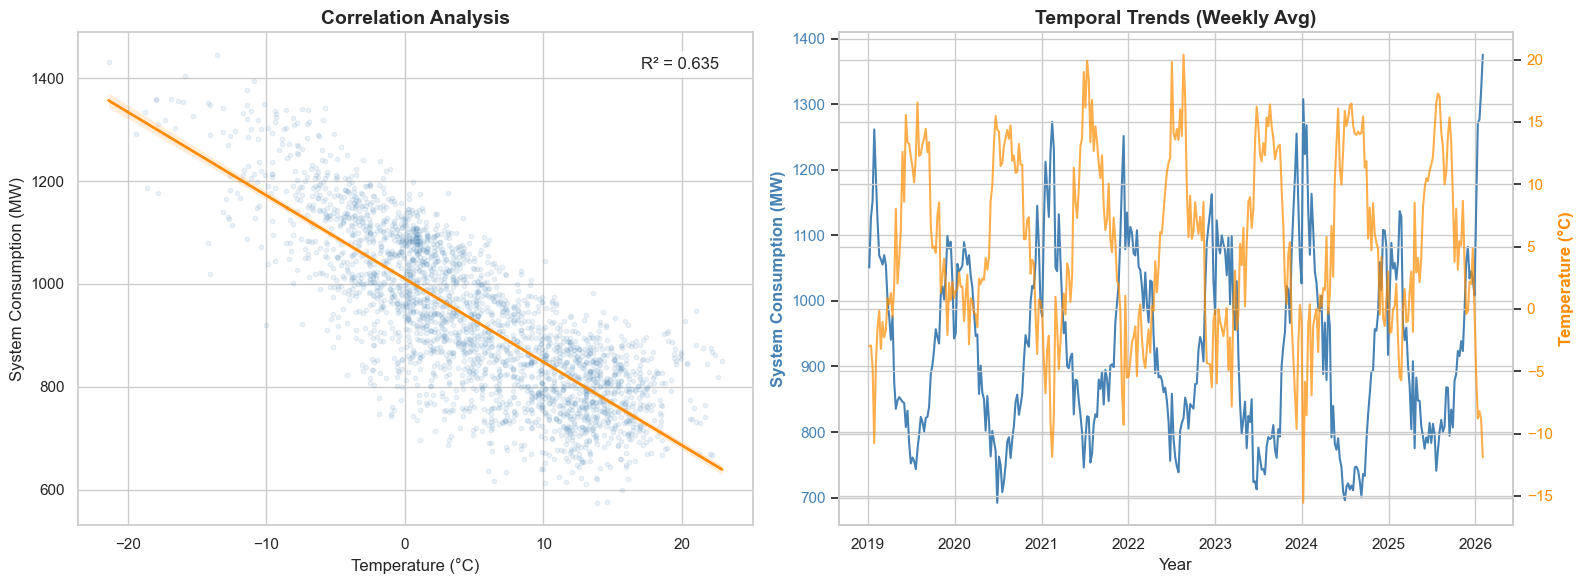

In [13]:
from scipy.stats import linregress


df_weather = hf.get_weather_openmeteo(
        lat=58.90, lon=24.75, start="2019-01-01T23:00:00.000Z", end="2026-01-31T22:59:59.999Z")

# 1. Data Preparation
df_merged = pd.merge(df_weather, df_electricity, on='timestamp', how='inner')
df_clean = df_merged.dropna(subset=['temperature', 'system_consumption'])

# Prepare Time Series (Resample to Weekly for a cleaner look side-by-side)
df_time = df_merged.resample('W').mean()

# 2. Calculate R-squared
slope, intercept, r_value, p_value, std_err = linregress(df_clean['temperature'], df_clean['system_consumption'])
r_squared = r_value ** 2

# 3. Create the Side-by-Side Plot
sns.set_theme(style="whitegrid")
fig, (ax_scatter, ax_time) = plt.subplots(1, 2, figsize=(16, 6))

# --- LEFT PLOT: Scatter + Regression ---
sns.regplot(
    data=df_clean,
    x='temperature',
    y='system_consumption',
    scatter_kws={'alpha': 0.1, 'color': 'steelblue', 's': 10},
    line_kws={'color': 'darkorange', 'linewidth': 2},
    ax=ax_scatter
)
ax_scatter.set_title('Correlation Analysis', fontsize=14, fontweight='bold')
ax_scatter.set_xlabel('Temperature (°C)')
ax_scatter.set_ylabel('System Consumption (MW)')
ax_scatter.text(0.95, 0.95, f'R² = {r_squared:.3f}', 
                transform=ax_scatter.transAxes, fontsize=12, 
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# --- RIGHT PLOT: Time Series with Dual Axes ---
ax_time.set_title('Temporal Trends (Weekly Avg)', fontsize=14, fontweight='bold')
ax_time.set_xlabel('Year')

# Consumption Axis
color_cons = 'steelblue'
ax_time.set_ylabel('System Consumption (MW)', color=color_cons, fontweight='bold')
ax_time.plot(df_time.index, df_time['system_consumption'], color=color_cons, linewidth=1.5)
ax_time.tick_params(axis='y', labelcolor=color_cons)

# Temperature Axis (Secondary)
ax_temp = ax_time.twinx()
color_temp = 'darkorange'
ax_temp.set_ylabel('Temperature (°C)', color=color_temp, fontweight='bold')
ax_temp.plot(df_time.index, df_time['temperature'], color=color_temp, linewidth=1.5, alpha=0.7)
ax_temp.tick_params(axis='y', labelcolor=color_temp)

plt.tight_layout()
plt.show()


**Correlation analysis: temperature vs. system consumption**

The scatter plot shows a strong negative relationship between outdoor
temperature and Estonia's system consumption, with an R² of 0.635.
As temperatures rise, electricity demand falls, which is the classic
heating-driven demand pattern: cold winters push consumption up toward
1200–1400 MW, while warm summers bring it down to 650–900 MW.

The relationship is fairly linear across the full range, though the
spread widens around 0–10°C, suggesting that mild temperatures introduce
more variability in behavior, likely because heating needs become
optional rather than necessary at that point.

**Temporal trends: consumption and temperature (2019–2026)**

The time series confirms the same story visually. Consumption (blue) and
temperature (orange) move in near-perfect opposition throughout the
period, with consumption peaking each winter and troughing each summer
in a regular seasonal cycle.

A few things stand out beyond the seasonality. First, there is a modest
downward drift in winter consumption peaks from 2019 onward, with the
highest peaks of around 1250–1275 MW in 2019–2021 giving way to
somewhat lower peaks in later years, possibly reflecting efficiency
improvements or the oil shale phase-out reducing industrial load.
Second, early 2026 shows a sharp spike in consumption coinciding with
what appears to be an unusually cold period, briefly reaching the
highest recorded level in the dataset at around 1375 MW.

Together, the two plots make a strong case for including temperature as
a feature in the GNN model, given its clear and consistent explanatory
power over demand.


## **4. Demand Simulation**

In [43]:
from timeseries_module import (
    run_pipeline,
    plot_january_demand_grid,
    plot_acf_pacf,
    plot_beta_by_year,
    plot_mc_simulations,
    plot_mc_uncertainty_band,
)

result = run_pipeline(
    n_sims=100,
    save_outputs=False,
    output_dir="../data",
    verbose=False,
)

KeyboardInterrupt: 

### **4.1 Data sources and preprocessing**

We collected electricity demand data from the Elering API for January in the years 2019–2026. The original data is sampled at 5-minute intervals and is therefore resampled to hourly averages. This reduces short-term noise while preserving the daily structure in electricity consumption.

To explain variations in demand, we include the following exogenous variables:

- **Temperature** using a 24-hour rolling average
- **Wind speed**
- **Weekend indicator**

Temperature is included because it is closely related to heating demand, especially during winter. Initially, we wanted to use industrial production as our second exogenous variables, since industrial activity significantly influences electricity demand. However, we were unable to access the industrial production API and therefore used wind speed instead (even though it is not directly tied to demand, but can still be used to induced some more uncertainty and show our understanding of working with beta parameters). The weekend indicator was chosen since it captures behavioural differences between weekdays and weekends.

### **4.2 Model choice**

As seen in the consumption plots from years 2019 to 2025 below, electricity demand shows clear daily seasonality, with recurring 24-hour consumption patterns. Because of this, we use a **SARIMAX model**, which extends the commonly used model for timeseries data, ARIMA, by allowing both seasonal time series structure and exogenous explanatory variables.



In [41]:
plot_january_demand_grid(result.demand_series, years=range(2019, 2026))

NameError: name 'plot_january_demand_grid' is not defined

Before fitting the final models, we inspect the autocorrelation function (ACF) and partial autocorrelation function (PACF) for the hourly demand series as well as the demand series lagged by 24 hours. This helps identify suitable autoregressive, differencing and moving average components, both for the seasonal and non seasonal part. Below, an example of these plots are shown for year 2024

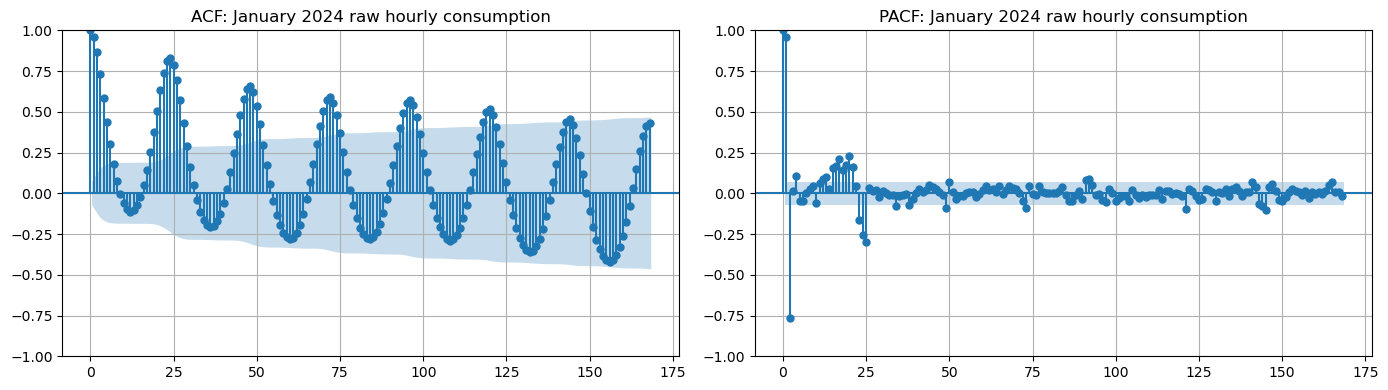

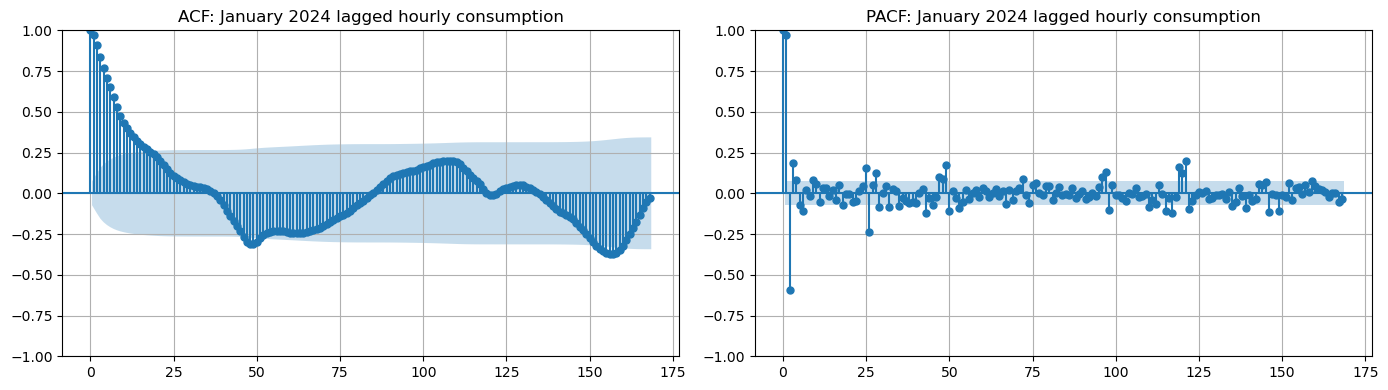

In [ ]:
plot_acf_pacf(result.demand_series[2024], "January 2024 raw hourly consumption")
plot_acf_pacf(result.demand_series[2024].diff(24), "January 2024 lagged hourly consumption")

Based off these plots, we have tested many different model candidates. Below, 4 of them are shown:

| Non-seasonal order | Seasonal order |
|---|---|
| (1, 0, 2) | (1, 1, 1, 24) |
| (2, 0, 2) | (1, 1, 1, 24) |
| (2, 0, 2) | (2, 1, 1, 24) |
| (2, 0, 2) | (1, 1, 2, 24) |

Here, the non-seasonal order is written as $(p, d, q)$, where $p$ is the autoregressive order, $d$ is the differencing order and $q$ is the moving average order. The seasonal order is written as $(P, D, Q, S)$, where $P$, $D$ and $Q$ are the seasonal components of $p$, $d$ and $q$, and $S = 24$ represents daily seasonality in hourly data.

The candidate models are fitted separately for each year from 2019 to 2025. They are then compared using the Bayesian Information Criterion (BIC), to prefer simpler models, as BIC punished many parameters. 

Below, the results of ranking these candidates each year are shown. 

In [ ]:
display(result.all_results_df)

,year,model_id,order,seasonal_order,AIC,BIC,Ljung-Box p-value lag 24,converged,error,score
0,2019,3,"(2, 0, 2)","(1, 1, 2, 24)",5390.067392,5439.631017,2.444462e-48,True,None,4
1,2019,2,"(2, 0, 2)","(2, 1, 1, 24)",5392.028066,5441.608121,6.071325e-68,True,None,3
2,2019,1,"(2, 0, 2)","(1, 1, 1, 24)",5607.270837,5652.681137,1.105321e-53,True,None,2
3,2019,0,"(1, 0, 2)","(1, 1, 1, 24)",5612.175911,5653.045181,5.943407e-66,True,None,1
4,2020,3,"(2, 0, 2)","(1, 1, 2, 24)",5400.016907,5449.580532,2.208572e-57,True,None,4
5,2020,2,"(2, 0, 2)","(2, 1, 1, 24)",5417.402624,5466.982679,5.090107e-54,True,None,3
6,2020,0,"(1, 0, 2)","(1, 1, 1, 24)",5613.729852,5654.599122,4.087483e-82,True,None,2
7,2020,1,"(2, 0, 2)","(1, 1, 1, 24)",5619.714213,5665.124513,1.033988e-52,True,None,1
8,2021,2,"(2, 0, 2)","(2, 1, 1, 24)",5384.565522,5434.145577,1.502517e-44,True,None,4
9,2021,3,"(2, 0, 2)","(1, 1, 2, 24)",5388.768958,5438.332582,1.051004e-34,True,None,3


It should be noted that the Ljung-Box p-value is nearly zero for all runs, which means that there are still some underlying patterns in the residuals, which we were unable to capture using our SARIMAX model. Nonetheless, our best-performing model across the historical years is:

> **SARIMAX(2, 0, 2)(1, 1, 2, 24)**

This model is then fitted separately to each year from 2019 to 2025 using the exogenous variables. Fitting the model separately for each year allows the estimated coefficients to vary across different Januaries.

---

### **4.3 Estimation of Weather Sensitivities**

Each fitted SARIMAX model estimates coefficients for the exogenous variables. These coefficients describe how the external variables influence electricity demand.

For example, if the coefficient for temperature is -4, this means that a 1°C increase in temperature is associated with an average decrease in demand of approximately 4 MW, all else equal.

Because these coefficients vary across years, we treat them as uncertain rather than fixed. For each exogenous variable, we estimate:

- The mean coefficient across fitted years
- The standard deviation across fitted years

This gives a simple empirical distribution for how strongly each exogenous variable may affect demand.

---

### **4.4 Monte Carlo Simulation of Demand**

After fitting the historical SARIMAX models, we simulate possible electricity demand outcomes for January 2026 using Monte Carlo simulation.

Each simulation is generated as follows:

1. A SARIMAX is fitted using the best performing model orders, and is randomly selected from one of the historical years 2019–2025.
2. A baseline forecast is generated using the observed January 2026 weather data.
3. New exogenous variable coefficients are sampled from the estimated cross-year coefficient distributions.
4. The forecast is adjusted according to the sampled coefficients.
5. Random residual noise is added based on the historical residual variation from the selected model.

This produces an ensemble of possible demand trajectories for January 2026.

The simulated demand paths reflect:

- **Model uncertainty**, since different historical years may produce different fitted models
- **Parameter uncertainty**, since the weather sensitivities are sampled from estimated distributions
- **Stochastic demand variation**, since residual noise is added to each simulation

Importantly, the simulation is conditional on the observed January 2026 weather. This means that we do not simulate alternative weather scenarios. Instead, the uncertainty comes from the demand model and from how strongly demand responds to the observed weather conditions.

These simulated demand scenarios are later combined with the supply-side simulations to evaluate how often the Estonian energy system may experience insufficient supply under uncertain demand.

The final Monte Carlo Plot is shown below:

In [ ]:
plot_mc_simulations(result.demand_mc, result.actual_target)

NameError: name 'plot_mc_simulations' is not defined

## **5. Wind Counterfactual Simulation**

Assessing whether new wind farms would have materially changed January 2026 requires two analytical steps. First, we establish the historical context of Estonia's existing wind fleet using actual ENTSOE Transparency Platform metered production data (2019–2025). Second, since the planned farms do not yet exist, we estimate their January 2026 output using ERA5 reanalysis weather and a physical turbine power curve model.

The full data pipelines are implemented as standalone scripts (all paths relative to `final_project/`):
- `wind_farm_locations.py` — loads Land Board GIS polygons from `data/wind_farm_locations/`, extracts polygon centroids → farm coordinates used below
- `wind_integration.py` — parses ENTSOE CSV exports from `data/historical_production_data/`, handles DST ambiguity, computes capacity factors → `../data/entsoe_production_hourly.csv`
- `wind_counterfactual.py` — fetches ERA5 weather per farm centroid via Open-Meteo, applies Vestas V150 power curve → `../data/wind_production_scenarios.csv`

**Data sources:**
- ENTSOE Transparency Platform: [transparency.entsoe.eu](https://transparency.entsoe.eu) — metered generation by type, 2019–2025, files in `data/historical_production_data/`
- Open-Meteo ERA5 archive API: [open-meteo.com/en/docs/historical-weather-api](https://open-meteo.com/en/docs/historical-weather-api) — free, no key required, ~9 km resolution
- Estonian Land Board (Maa-amet) — wind-energy planning-area GeoJSON files in `data/wind_farm_locations/`
- Elering annual reports — installed wind capacity timeline (310 MW 2019 → 694 MW 2025)

### 5.1 Historical Wind Context (ENTSOE 2019–2025)

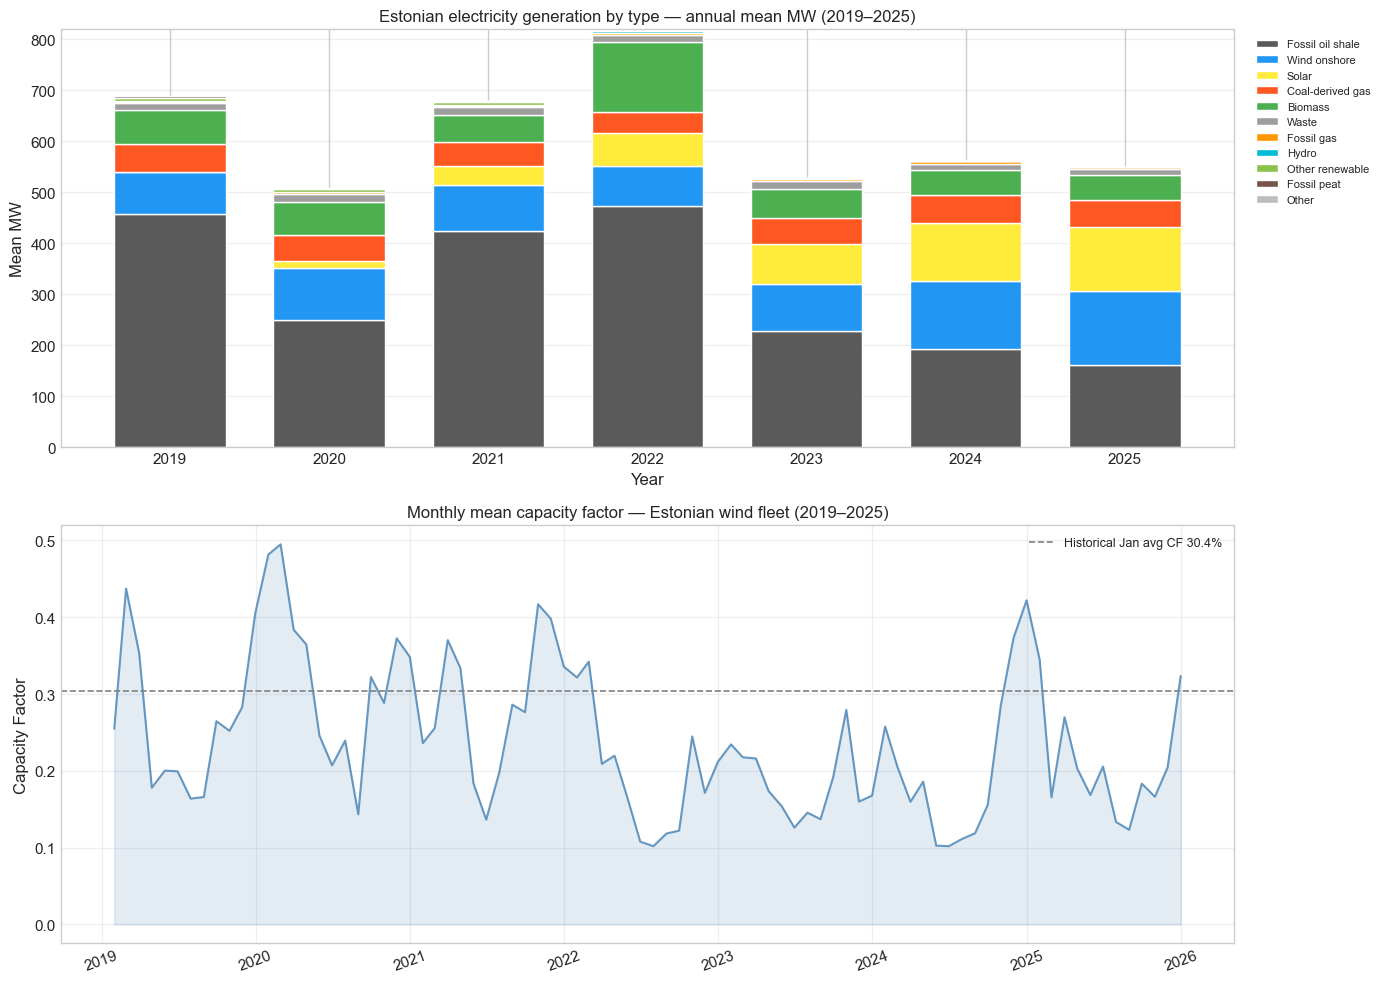

Historical January mean CF (2019–2025): 0.304
January 2026 counterfactual CF (ERA5):   0.152  (about half the average)


In [45]:
os.makedirs("../figures", exist_ok=True)

RENAME = {
    "fossil_oil_shale":               "Fossil oil shale",
    "biomass":                        "Biomass",
    "wind_onshore":                   "Wind onshore",
    "fossil_gas":                     "Fossil gas",
    "fossil_peat":                    "Fossil peat",
    "waste":                          "Waste",
    "other_renewable":                "Other renewable",
    "other":                          "Other",
    "solar":                          "Solar",
    "hydro_run-of-river_and_pondage": "Hydro",
    "fossil_coal-derived_gas":        "Coal-derived gas",
}
COLORS = {
    "Fossil oil shale": "#5a5a5a", "Biomass": "#4caf50",    "Wind onshore": "#2196f3",
    "Fossil gas":       "#ff9800", "Fossil peat": "#795548", "Waste": "#9e9e9e",
    "Other renewable":  "#8bc34a", "Other": "#bdbdbd",       "Solar": "#ffeb3b",
    "Hydro":            "#00bcd4", "Coal-derived gas": "#ff5722",
}

try:
    entsoe = pd.read_csv("data/entsoe_production_hourly.csv", index_col=0, parse_dates=True)
    gen_cols = [c for c in entsoe.columns if c not in ("capacity_factor", "installed_mw")]

    annual = entsoe[gen_cols].loc["2019":"2025"].resample("YE").mean()
    annual.index = annual.index.year
    annual_named = annual.rename(columns=RENAME).fillna(0)
    col_order = annual_named.loc[2025].sort_values(ascending=False).index.tolist()
    annual_named = annual_named[col_order]

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Plot 1: Annual energy mix stacked bar
    bottom = np.zeros(len(annual_named))
    for col in col_order:
        vals = annual_named[col].values
        axes[0].bar(annual_named.index, vals, bottom=bottom,
                    label=col, color=COLORS.get(col, "#aaaaaa"), width=0.7)
        bottom += vals
    axes[0].set_title("Estonian electricity generation by type — annual mean MW (2019–2025)", fontsize=12)
    axes[0].set_ylabel("Mean MW")
    axes[0].set_xlabel("Year")
    axes[0].set_xticks(annual_named.index)
    axes[0].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    axes[0].grid(axis="y", alpha=0.3)

    # Plot 2: Monthly capacity factor
    cf_monthly = entsoe["capacity_factor"].loc["2019":"2025"].resample("ME").mean()
    axes[1].plot(cf_monthly.index, cf_monthly.values, color="steelblue", lw=1.5, alpha=0.8)
    axes[1].axhline(0.304, color="gray", lw=1.2, linestyle="--", label="Historical Jan avg CF 30.4%")
    axes[1].fill_between(cf_monthly.index, cf_monthly.values, alpha=0.15, color="steelblue")
    axes[1].set_title("Monthly mean capacity factor — Estonian wind fleet (2019–2025)", fontsize=12)
    axes[1].set_ylabel("Capacity Factor")
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)
    axes[1].tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.savefig("../figures/entsoe_historical_wind.png", dpi=150, bbox_inches="tight")
    plt.show()

    jan_cf = entsoe.loc[entsoe.index.month == 1, "capacity_factor"].mean()
    print(f"Historical January mean CF (2019–2025): {jan_cf:.3f}")
    print(f"January 2026 counterfactual CF (ERA5):   0.152  (about half the average)")
except FileNotFoundError as e:
    print(f"Missing: {e}\nRun: python wind_integration.py")

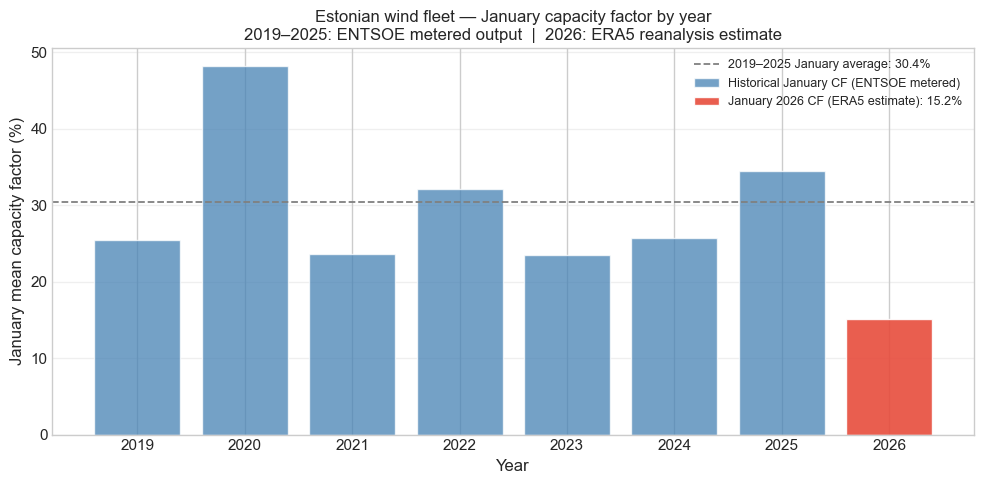

January mean capacity factors:
  2019: 25.5%
  2020: 48.2%
  2021: 23.6%
  2022: 32.2%
  2023: 23.4%
  2024: 25.8%
  2025: 34.5%
  2026 (ERA5): 15.2%  ← lowest on record


In [46]:
try:
    entsoe = pd.read_csv("data/entsoe_production_hourly.csv", index_col=0, parse_dates=True)
    wind_scen = pd.read_csv("data/wind_production_scenarios.csv", index_col=0, parse_dates=True)
    if wind_scen.index.tz is None:
        wind_scen.index = wind_scen.index.tz_localize("UTC")

    jan_hist = entsoe[entsoe.index.month == 1]
    jan_cf_by_year = jan_hist.groupby(jan_hist.index.year)["capacity_factor"].mean()
    jan26_cf = wind_scen["wind_mwh_baseline"].mean() / 694

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(jan_cf_by_year.index, jan_cf_by_year.values * 100,
           color="steelblue", alpha=0.75, label="Historical January CF (ENTSOE metered)")
    ax.bar([2026], [jan26_cf * 100], color="#e74c3c", alpha=0.9,
           label=f"January 2026 CF (ERA5 estimate): {jan26_cf*100:.1f}%")
    ax.axhline(jan_cf_by_year.mean() * 100, color="gray", lw=1.3, linestyle="--",
               label=f"2019\u20132025 January average: {jan_cf_by_year.mean()*100:.1f}%")
    ax.set_xlabel("Year")
    ax.set_ylabel("January mean capacity factor (%)")
    ax.set_title("Estonian wind fleet \u2014 January capacity factor by year\n"
                 "2019\u20132025: ENTSOE metered output  |  2026: ERA5 reanalysis estimate")
    ax.set_xticks(list(jan_cf_by_year.index) + [2026])
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("../figures/jan_cf_by_year.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("January mean capacity factors:")
    for yr, cf in jan_cf_by_year.items():
        print(f"  {yr}: {cf*100:.1f}%")
    print(f"  2026 (ERA5): {jan26_cf*100:.1f}%  \u2190 lowest on record")
except FileNotFoundError as e:
    print(f"Missing: {e}")

### 5.2 Counterfactual Scenarios — Farm Locations and Methodology

Since the planned farms do not yet exist, there is no metered output to download. We estimate production using **ERA5 reanalysis wind speeds at 100 m** (from Open-Meteo's free archive API) at each farm's GIS centroid, combined with a **Vestas V150-4.5 MW power curve** and an air-density correction for cold January conditions. A flat capacity addition would assume every new MW operates at the same average CF as the existing fleet — ignoring that specific farm locations have different wind regimes and that calm-wind hours (when the crisis was worst) affect all sites simultaneously. The ERA5 + power curve approach captures this hour-by-hour variability.

**Scenario A — established plans (+323 MW, total 1,017 MW):**

| Farm | Capacity | Planning status | Source file |
|------|----------|----------------|-------------|
| Lääneranna (area 2) | 137 MW | Valid special plan (*kehtestatud eriplaneeringu asukoha eelvalik*) | `tuul_ep_kehtestatud.geojson` |
| Pärnu + Tori (Põlendmaa) | 86 MW | Valid special plan | `tuul_ep_kehtestatud.geojson` |
| Aidu renewable energy park | 100 MW | Valid detailed plan (*kehtestatud detailplaneering*) | `tuulealad_DP.geojson` |

**Scenario B — pipeline plans (+564 MW on top of A, total 1,581 MW):**

| Farm | Capacity | Planning status | Source file |
|------|----------|----------------|-------------|
| Lääneranna (pipeline areas) | 150 MW | SEA report adopted, moving towards implementation | `tuuleenergeetika_KOV_EP_alad.geojson` |
| Tori rural municipality | 100 MW | SEA report adopted | `tuuleenergeetika_KOV_EP_alad.geojson` |
| Lääne-Nigula | 100 MW | Location decision published | `tuuleenergeetika_KOV_EP_alad.geojson` |
| Põhja-Pärnumaa | 100 MW | Draft stage I and SEA published | `tuuleenergeetika_KOV_EP_alad.geojson` |
| Lüganuse (Evecon + Enery Estonia) | 114 MW | Draft stage I and SEA published | `tuuleenergeetika_KOV_EP_alad.geojson` |

*GIS source: Estonian Land Board (Maa-amet) planning-area GeoJSON files in `data/wind_farm_locations/`. Capacity figures for Scenario A are from the officially enacted planning documents. Scenario B capacities are proportional estimates based on planning-area polygon size (7 MW/km²) as exact MW have not yet been published. Farm coordinates derived by `wind_farm_locations.py` (polygon centroid extraction, EPSG:4326).*

> **Note — onshore only:** Estonia currently has **no offshore wind farms**. All 694 MW of installed capacity, and all farms in Scenarios A and B, are onshore. The Utilitas Liivi Bay offshore project referenced in the introduction [5] would be a separate, much larger category and is not included in this counterfactual.

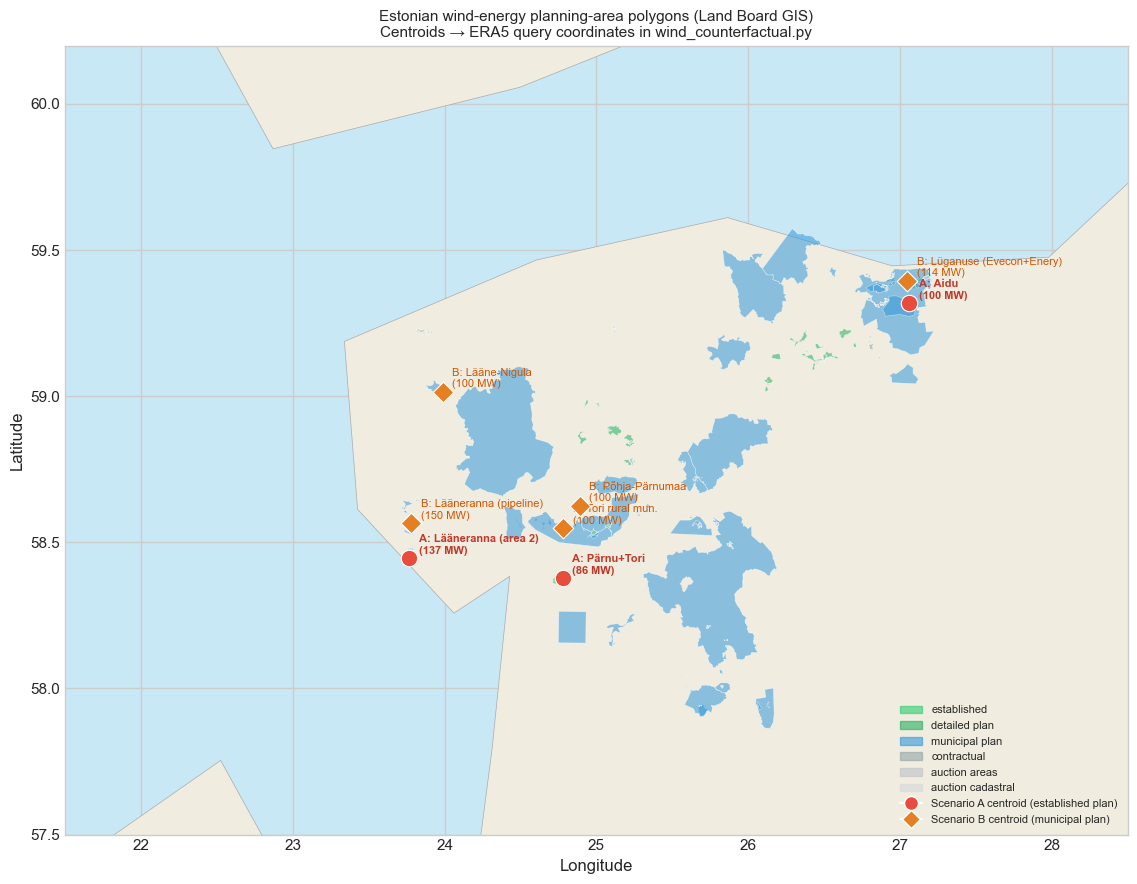

Full GIS pipeline: wind_farm_locations.py


In [ ]:
import geopandas as gpd
import matplotlib.patches as mpatches
import importlib

GIS_DIR = "data/wind_farm_locations"

LON_MIN, LON_MAX = 21.5, 28.5
LAT_MIN, LAT_MAX = 57.5, 60.2

FILES = {
    "tuul_ep_kehtestatud.geojson":                    ("established",       "#2ecc71"),
    "tuulealad_DP.geojson":                           ("detailed plan",     "#27ae60"),
    "tuuleenergeetika_KOV_EP_alad.geojson":           ("municipal plan",    "#3498db"),
    "RMK_MARU_lepingus.geojson":                      ("contractual",       "#95a5a6"),
    "Riigimaade_enampakkumine_voor_alad.geojson":     ("auction areas",     "#bdc3c7"),
    "Riigimaade_enampakkumine_voor_kataster.geojson": ("auction cadastral", "#d5d8dc"),
}
SCEN_A = {
    "Lääneranna valla tuuleparkide eriplaneeringu kehtestamine ala 2 osas":
        ("Lääneranna (area 2)", 137, 58.4473, 23.7673),
    "Pärnu linna tuuleenergeetika eriplaneeringu kehtestamine (Põlendmaa)":
        ("Pärnu+Tori", 86, 58.3775, 24.7786),
    "Aidu ja Aidu-Liiva":
        ("Aidu", 100, 59.3195, 27.0613),
}
SCEN_B = [
    ("Lääneranna (pipeline)", 150, 58.5658, 23.7781),
    ("Tori rural mun.",       100, 58.5496, 24.7787),
    ("Lääne-Nigula",          100, 59.0159, 23.9870),
    ("Põhja-Pärnumaa",        100, 58.6254, 24.8906),
    ("Lüganuse (Evecon+Enery)", 114, 59.3959, 27.0476),
]

try:
    fig, ax = plt.subplots(figsize=(13, 9))
    ax.set_facecolor("#c9e8f5")

    land = None
    try:
        _gds = importlib.import_module("geodatasets")
        land = gpd.read_file(_gds.get_path("naturalearth.land"))
    except Exception:
        try:
            _ds = getattr(gpd, "datasets", None)
            if _ds is not None:
                land = gpd.read_file(_ds.get_path("naturalearth_lowres"))
        except Exception:
            pass
    if land is not None:
        land.cx[LON_MIN:LON_MAX, LAT_MIN:LAT_MAX].plot(
            ax=ax, color="#f0ede0", edgecolor="#aaaaaa", linewidth=0.5, zorder=1)

    for fname, (label, color) in FILES.items():
        gdf = gpd.read_file(f"{GIS_DIR}/{fname}")
        if gdf.crs is None:
            gdf = gdf.set_crs(epsg=4326)
        elif gdf.crs.to_epsg() != 4326:
            gdf = gdf.to_crs(epsg=4326)
        gdf.plot(ax=ax, color=color, alpha=0.55, edgecolor="white", linewidth=0.4, zorder=2)

    for name, (lbl, mw, lat, lon) in SCEN_A.items():
        ax.scatter(lon, lat, s=140, color="#e74c3c", zorder=6, edgecolors="white", linewidths=0.8)
        ax.annotate(f"A: {lbl}\n({mw} MW)", (lon, lat),
                    textcoords="offset points", xytext=(7, 3),
                    fontsize=8, color="#c0392b", fontweight="bold")
    for lbl, mw, lat, lon in SCEN_B:
        ax.scatter(lon, lat, s=110, color="#e67e22", zorder=5, marker="D",
                   edgecolors="white", linewidths=0.8)
        ax.annotate(f"B: {lbl}\n({mw} MW)", (lon, lat),
                    textcoords="offset points", xytext=(7, 3),
                    fontsize=8, color="#d35400")

    ax.set_xlim(LON_MIN, LON_MAX)
    ax.set_ylim(LAT_MIN, LAT_MAX)
    patches = [mpatches.Patch(color=c, alpha=0.6, label=l) for _, (l, c) in FILES.items()]
    patches += [
        plt.Line2D([0],[0], marker="o", color="w", markerfacecolor="#e74c3c",
                   markersize=10, label="Scenario A centroid (established plan)"),
        plt.Line2D([0],[0], marker="D", color="w", markerfacecolor="#e67e22",
                   markersize=9, label="Scenario B centroid (municipal plan)"),
    ]
    ax.legend(handles=patches, fontsize=8, loc="lower right", framealpha=0.9)
    ax.set_title("Estonian wind-energy planning-area polygons (Land Board GIS)\n"
                 "Centroids → ERA5 query coordinates in wind_counterfactual.py", fontsize=11)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.tight_layout()
    plt.savefig("../figures/wind_farm_gis_map.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Full GIS pipeline: wind_farm_locations.py")
except Exception as e:
    print(f"Error: {e}")
    print("Requires geopandas. Install geodatasets for land background: pip install geodatasets")

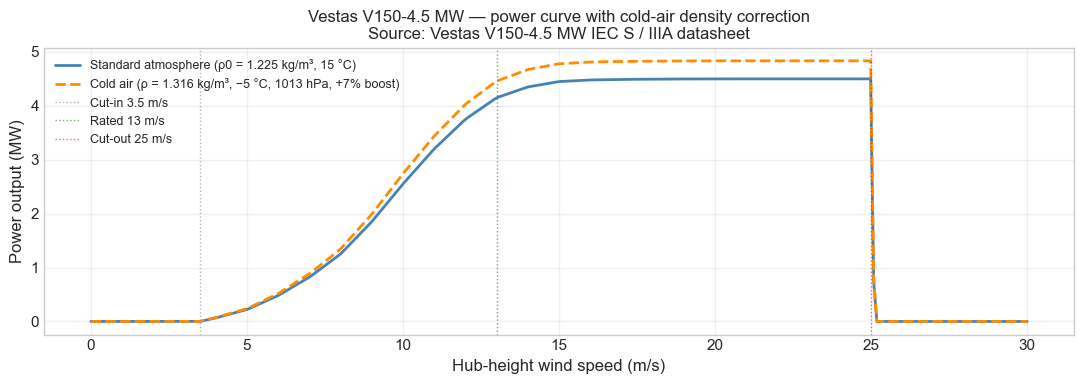

Air density at −5 °C, 1013 hPa: 1.3161 kg/m³  (+7.4% vs standard)


In [37]:
import numpy as np

# Vestas V150-4.5 MW power curve (cut-in ~3.5 m/s, rated ~13 m/s, cut-out 25 m/s)
# Source: Vestas V150-4.5 MW IEC S / IIIA datasheet
PC_WS = np.array([0,1,2,3,3.5,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,25.1,50])
PC_KW = np.array([0,0,0,0,  0,66,220,480,820,1250,1850,2550,3200,3750,4150,4350,4450,4480,4490,4495,4498,4500,4500,4500,4500,4500,4500,0,0])

v = np.linspace(0, 30, 300)
rho_std  = 1.225
rho_cold = (1013 * 100) / (287.05 * (-5 + 273.15))
boost_pct = (rho_cold / rho_std - 1) * 100

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(v, np.interp(v, PC_WS, PC_KW) / 1000,
        color="steelblue", lw=2, label=f"Standard atmosphere (\u03c10 = 1.225 kg/m\u00b3, 15 \u00b0C)")
ax.plot(v, np.interp(v, PC_WS, PC_KW) * (rho_cold / rho_std) / 1000,
        color="darkorange", lw=2, linestyle="--",
        label=f"Cold air (\u03c1 = {rho_cold:.3f} kg/m\u00b3, \u22125 \u00b0C, 1013 hPa, +{boost_pct:.0f}% boost)")
ax.axvline(3.5, color="gray",  lw=1, linestyle=":", alpha=0.6, label="Cut-in 3.5 m/s")
ax.axvline(13,  color="green", lw=1, linestyle=":", alpha=0.6, label="Rated 13 m/s")
ax.axvline(25,  color="red",   lw=1, linestyle=":", alpha=0.6, label="Cut-out 25 m/s")
ax.set_xlabel("Hub-height wind speed (m/s)")
ax.set_ylabel("Power output (MW)")
ax.set_title("Vestas V150-4.5 MW — power curve with cold-air density correction\n"
             "Source: Vestas V150-4.5 MW IEC S / IIIA datasheet")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/power_curve_v150.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Air density at \u22125 \u00b0C, 1013 hPa: {rho_cold:.4f} kg/m\u00b3  (+{boost_pct:.1f}% vs standard)")

### 5.3 Power Curve Model

**Hub-height wind speed.** The Vestas V150 hub sits at 105 m. ERA5 provides `wind_speed_100m` at 100 m — 5 m below hub. Applying the standard power-law wind shear correction gives a factor of $(105/100)^{0.143} \approx 1.007$, a 0.7% difference negligible compared to ERA5 reanalysis uncertainty. The 100 m wind speed is therefore used directly as the hub-height proxy.

**Air density correction.** The published power curve assumes standard atmosphere ($\rho_0 = 1.225$ kg/m³ at 15 °C, sea level). Cold, dense winter air contains more kinetic energy per cubic metre. ERA5 provides hourly temperature $T$ (°C) and surface pressure $p$ (hPa), from which air density is computed via the ideal gas law:

$$\rho = \frac{p \times 100}{287.05 \times (T + 273.15)} \quad \text{[kg/m}^3\text{]}$$

Because turbine power scales with air density, the corrected output is:

$$P_\text{adj}(v) = P_\text{nominal}(v) \times \frac{\rho}{\rho_0}$$

At the January 2026 crisis conditions (around −5 °C, 1013 hPa), $\rho \approx 1.316$ kg/m³ — roughly 7% above standard — giving a ~7% power boost relative to the IEC reference condition. Cold temperatures therefore slightly *favour* turbine output, working in Estonia's direction during the crisis.

**Capacity factor and farm production.** The capacity factor at each hour is $\text{CF} = \min(1,\; P_\text{adj} / 4500\text{ kW})$. Multiplied by each farm's installed MW and summed across farms, this gives total hourly wind production per scenario.

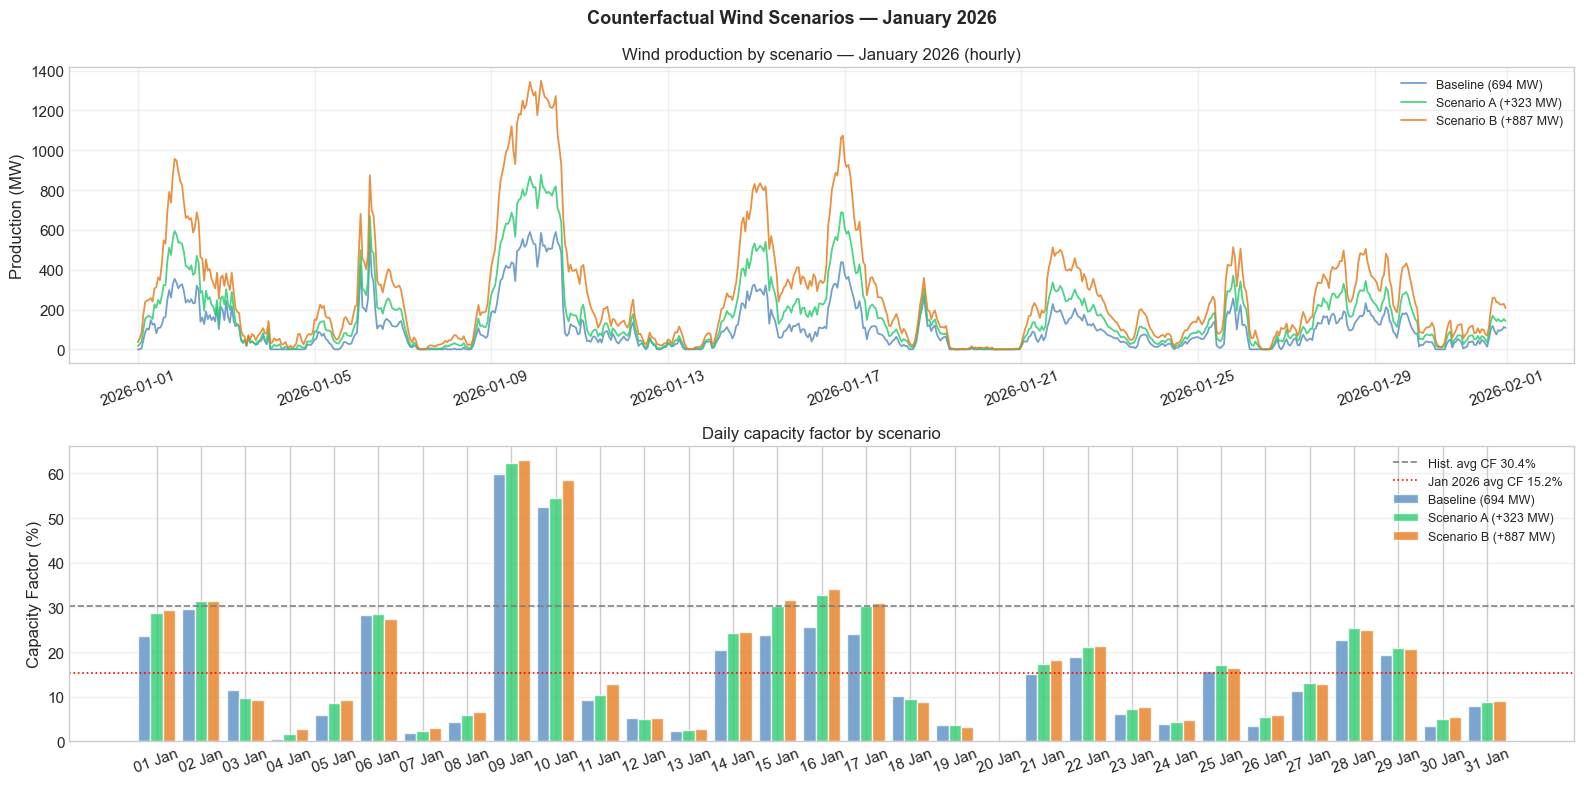

Mean production (MW):
  Baseline (694 MW)           : 105.3 MW  (CF 15.2%)
  Scenario A (+323 MW)        : 173.1 MW  (CF 17.0%)
  Scenario B (+887 MW)        : 276.3 MW  (CF 17.5%)


In [47]:
try:
    wind_df = pd.read_csv("data/wind_production_scenarios.csv", index_col=0, parse_dates=True)
    if wind_df.index.tz is None:
        wind_df.index = wind_df.index.tz_localize("UTC")

    wind_df = wind_df.rename(columns={
        "wind_mwh_baseline": "Baseline (694 MW)",
        "wind_mwh_scenA":    "Scenario A (+323 MW)",
        "wind_mwh_scenB":    "Scenario B (+887 MW)",
    })
    RATED = {"Baseline (694 MW)": 694, "Scenario A (+323 MW)": 1017, "Scenario B (+887 MW)": 1581}
    SCEN_COLORS = ["#5a8fc2", "#2ecc71", "#e67e22"]
    daily = wind_df.resample("D").mean()

    fig, axes = plt.subplots(2, 1, figsize=(16, 8))

    # Hourly time series
    for col, clr in zip(wind_df.columns, SCEN_COLORS):
        axes[0].plot(wind_df.index, wind_df[col].values, color=clr, lw=1.3, alpha=0.85, label=col)
    axes[0].set_title("Wind production by scenario — January 2026 (hourly)")
    axes[0].set_ylabel("Production (MW)")
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)
    axes[0].tick_params(axis="x", rotation=20)

    # Daily capacity factor
    x = np.arange(len(daily))
    w = 0.28
    for i, (col, clr) in enumerate(zip(daily.columns, SCEN_COLORS)):
        cf = daily[col] / RATED[col] * 100
        axes[1].bar(x + (i - 1) * w, cf.values, w, color=clr, alpha=0.8, label=col)
    axes[1].axhline(30.4, color="gray", lw=1.2, linestyle="--", label="Hist. avg CF 30.4%")
    axes[1].axhline(15.2, color="red",  lw=1.2, linestyle=":",  label="Jan 2026 avg CF 15.2%")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([d.strftime("%d %b") for d in daily.index], rotation=20)
    axes[1].set_title("Daily capacity factor by scenario")
    axes[1].set_ylabel("Capacity Factor (%)")
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3, axis="y")

    plt.suptitle("Counterfactual Wind Scenarios — January 2026", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("figures/wind_scenarios_jan2026.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("Mean production (MW):")
    for col in wind_df.columns:
        print(f"  {col:28s}: {wind_df[col].mean():.1f} MW  (CF {wind_df[col].mean()/RATED[col]*100:.1f}%)")
except FileNotFoundError as e:
    print(f"Missing: {e}\nRun: python wind_counterfactual.py")

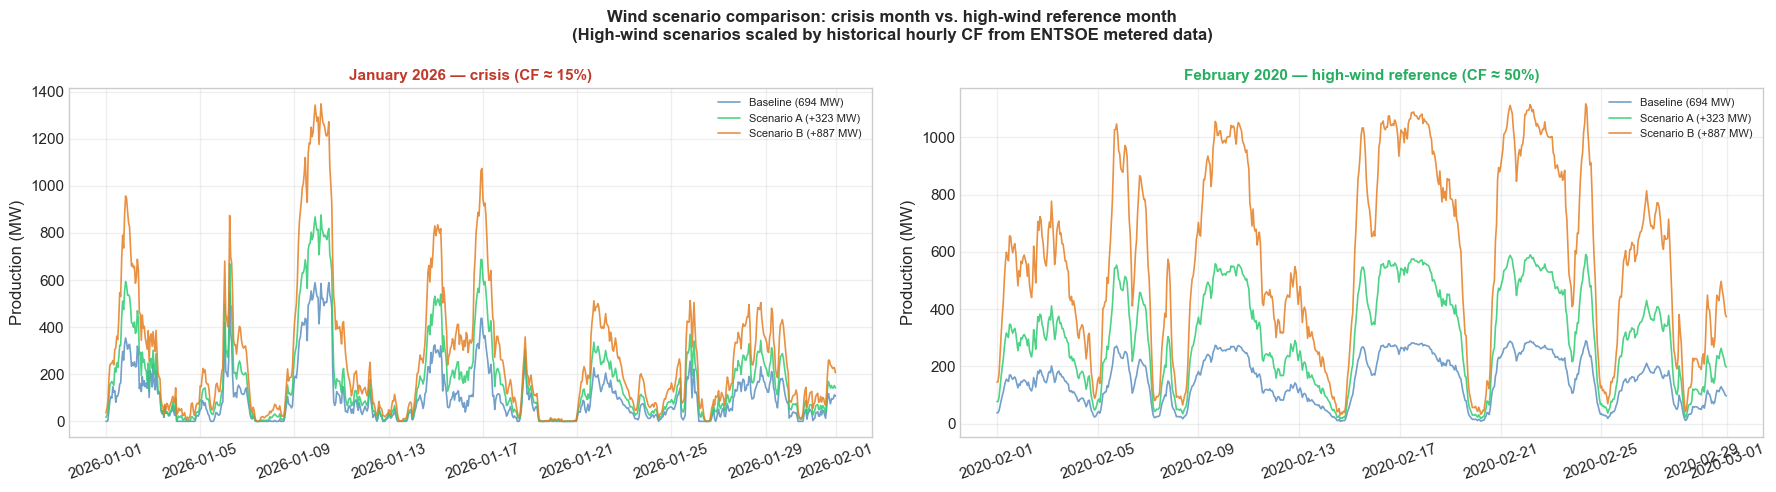

January 2026  — mean baseline: 105 MW  | scenA: 173 MW  | scenB: 276 MW
February 2020 — mean baseline: 153 MW  | scenA: 313 MW  | scenB: 593 MW


In [40]:
try:
    entsoe = pd.read_csv("data/entsoe_production_hourly.csv", index_col=0, parse_dates=True)
    wind_df = pd.read_csv("data/wind_production_scenarios.csv", index_col=0, parse_dates=True)
    if wind_df.index.tz is None:
        wind_df.index = wind_df.index.tz_localize("UTC")

    # Find the highest-CF full month in 2019–2025 (at least 28*24 hours of data)
    monthly_cf = entsoe["capacity_factor"].loc[:"2025-12"].resample("ME").agg(
        lambda x: x.mean() if len(x) >= 24*28 else float("nan")
    ).dropna()
    best_ts = monthly_cf.idxmax()
    best_label = best_ts.strftime("%B %Y")

    best = entsoe.loc[best_ts.strftime("%Y-%m")]
    base_mw  = best["wind_onshore"].fillna(0)
    cf_hour  = best["capacity_factor"].fillna(0)
    scenA_best = base_mw + cf_hour * 323
    scenB_best = base_mw + cf_hour * 887

    # January 2026 data already loaded
    j26 = wind_df.rename(columns={
        "wind_mwh_baseline": "Baseline (694 MW)",
        "wind_mwh_scenA":    "Scenario A (+323 MW)",
        "wind_mwh_scenB":    "Scenario B (+887 MW)",
    })

    SCEN_COLORS = ["#5a8fc2", "#2ecc71", "#e67e22"]
    fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=False)

    # Left: January 2026 (crisis)
    for col, clr in zip(j26.columns, SCEN_COLORS):
        axes[0].plot(j26.index, j26[col].values, color=clr, lw=1.2, alpha=0.85, label=col)
    axes[0].set_title(f"January 2026 — crisis (CF ≈ 15%)", fontsize=11, fontweight="bold", color="#c0392b")
    axes[0].set_ylabel("Production (MW)")
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)
    axes[0].tick_params(axis="x", rotation=20)

    # Right: best historical month
    axes[1].plot(best.index, base_mw.values,     color=SCEN_COLORS[0], lw=1.2, alpha=0.85, label="Baseline (694 MW)")
    axes[1].plot(best.index, scenA_best.values,  color=SCEN_COLORS[1], lw=1.2, alpha=0.85, label="Scenario A (+323 MW)")
    axes[1].plot(best.index, scenB_best.values,  color=SCEN_COLORS[2], lw=1.2, alpha=0.85, label="Scenario B (+887 MW)")
    axes[1].set_title(f"{best_label} — high-wind reference (CF ≈ {monthly_cf[best_ts]*100:.0f}%)",
                      fontsize=11, fontweight="bold", color="#27ae60")
    axes[1].set_ylabel("Production (MW)")
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)
    axes[1].tick_params(axis="x", rotation=20)

    plt.suptitle("Wind scenario comparison: crisis month vs. high-wind reference month\n"
                 "(High-wind scenarios scaled by historical hourly CF from ENTSOE metered data)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("../figures/wind_scenario_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"January 2026  — mean baseline: {j26['Baseline (694 MW)'].mean():.0f} MW  "
          f"| scenA: {j26['Scenario A (+323 MW)'].mean():.0f} MW  "
          f"| scenB: {j26['Scenario B (+887 MW)'].mean():.0f} MW")
    print(f"{best_label} — mean baseline: {base_mw.mean():.0f} MW  "
          f"| scenA: {scenA_best.mean():.0f} MW  "
          f"| scenB: {scenB_best.mean():.0f} MW")
except FileNotFoundError as e:
    print(f"Missing: {e}")

### 5.4 Key Findings

January 2026 was the lowest-wind January on record for Estonia's fleet, with an ERA5-estimated capacity factor of approximately **15.2%** against a 2019–2025 January average of ~30.4% (ENTSOE metered). The comparison with a high-wind reference month above shows what the same scenarios produce when the fleet runs near its potential: in a good-wind month the Scenario B additions (~887 MW) can contribute several hundred MW of additional output. During January 2026, the same capacity added only ~171 MW on average — and near zero in the calm-wind hours that drove the price spikes.

Key results under January 2026 actual weather:
- **Baseline (694 MW):** ~105 MW mean production (CF ≈ 15%)
- **Scenario A (+323 MW → 1,017 MW total):** ~173 MW mean  (+68 MW over baseline)
- **Scenario B (+887 MW → 1,581 MW total):** ~276 MW mean  (+171 MW over baseline)

**Why wind alone cannot solve the crisis.** During the worst hours — when demand peaked and prices hit €505/MWh — wind from all three scenarios simultaneously approached zero. Additional onshore capacity reduces the frequency and average depth of deficits, but provides no firm power during calm-wind events. Storage or dispatchable backup is required to cover the residual.

**Context on Estonia's wind mix.** All 694 MW of currently installed capacity, and all farms modelled in Scenarios A and B, are **onshore**. Estonia has no offshore wind in operation. The Utilitas Liivi Bay offshore project [5] would face different wind regimes (stronger, more consistent sea winds) and is therefore not directly comparable to the onshore counterfactuals estimated here.

## **6. Supply Analysis: Spatio-Temporal GNN**


Forecasting electricity prices in the Estonian grid is a challenging problem due to two compounding sources of complexity. First, supply-side uncertainty is high, as generation depends heavily on variable renewables such as wind, whose output is inherently difficult to predict. Second, Estonia operates within the interconnected Nordic-Baltic electricity market, meaning prices are strongly influenced by cross-border flows from neighboring bidding zones: Latvia, Lithuania, and Finland. Ignoring these spatial dependencies risks producing systematically biased forecasts.

These characteristics motivate a model that is both temporally aware and spatially structured. We represent the Nordic-Baltic grid as a graph, with bidding zones as nodes and physical cross-border transmission flows as edges, and apply a Spatio-Temporal Graph Neural Network (ST-GNN) ([Hadou et al., 2022](https://doi.org/10.48550/arXiv.2110.02880)). ST-GNNs are well-suited to this setting, as they jointly learn spatial dependencies across graph nodes and temporal dynamics across time steps, offering greater flexibility than univariate time series models. However, this flexibility comes at a cost: ST-GNNs require substantially more data, are harder to interpret, and are sensitive to the quality of the graph structure provided. The model is trained on seven years of hourly data (2019–2025) from the [Elering API](https://dashboard.elering.ee/assets/swagger-ui/index.html), supplemented with weather data from [Open-Meteo API](https://archive-api.open-meteo.com/v1/archive) and actual wind generation from [ENTSO-E API](https://transparency.entsoe.eu).

### Data and features

The Elering API data provided hourly production, renewable production, 
electricity prices, and cross-border import/export flows between Estonia 
and Finland, Latvia, Lithuania, and Russia (the latter disconnected from 
the Baltic grid on February 8, 2025
([ERR News, 2024](https://news.err.ee/1609367879/baltics-to-leave-brell-electricity-grid-at-start-of-february-2025);
[Wikipedia](https://en.wikipedia.org/wiki/Baltic_states_synchronization_with_CESA)).
All data was originally recorded at 15-minute or hourly resolution and 
aligned to a common hourly frequency.

The target variable is Estonian domestic energy production (MW). We 
initially considered "available energy", (defined as domestic production 
adjusted for cross-border flows), as the target, since it represents the 
total energy available for consumption. However, this formulation led to 
poorer model performance, as the input features primarily capture drivers 
of domestic production rather than cross-border flows. The added noise 
from flow dynamics made underlying trends harder to learn. We therefore 
use Estonian domestic energy production (MW) as the target variable, and then considered "available energy" for scenario visualizations.

Input features include production, available energy (production + import − export), renewable production, cross-border flows to Finland and Latvia, electricity prices, 
temperature, wind speed, and actual wind generation. The model uses a 48-hour 
sliding input window (t−48 to t−1) to predict production 24 hours ahead (t+24), 
so all features are strictly historical with no leakage. Explicit 24-hour lags of 
production and available energy are additionally included, extending the model's 
effective lookback to 72 hours and allowing it to directly observe the same hour 
on the previous two days. Weather variables (temperature and wind speed at 10 m) and cyclic calendar 
encodings (hour, day-of-week, month) are also included, alongside actual 
metered wind generation from [ENTSO-E](https://transparency.entsoe.eu), 
which gives the model a direct view of the wind component within total 
production. Finally, grid frequency deviation from 50 Hz is included as 
a measure of real-time supply-demand imbalance across the synchronous grid, ([grid stability signal](https://www.neso.energy/energy-101/electricity-explained/how-do-we-balance-grid/what-frequency)).

No unnecessary lags are applied to current-state measurements such as production or flows, as these reflect the state of the system at forecast time and are fully observable. All of this input data is fetched from the corresponding APIs.
The 24-hour lag is retained only for features where yesterday's value at the same hour carries a predictive signal beyond the current reading.


### Graph structure

The four bidding zones — Estonia (EE), Finland (FI), Latvia (LV), and Lithuania (LT) — form the nodes of the graph (implemented in Supply_wind.py). Edges represent active cross-border interconnections, with Estonia connected to Finland and Latvia, and Latvia connected to Lithuania, illustrated in Figure 1. All edges are bidirectional and weighted by the absolute mean historical flow magnitude on each interconnector, normalised to [0, 1] by dividing by the maximum edge weight prior to training.
Estonia, as the target node, carries the full feature set described above. The neighboring nodes (FI, LV, LT) carry a reduced feature set consisting of their local electricity prices and the cross-border flows directed toward Estonia (zero for (EE, LT) flow), reflecting the information that is physically transmitted across the interconnections. This asymmetry in node features is intentional: Estonia contains substantially more features than its neighbors, as the model is trained to predict Estonian domestic production.

<img src="../figures/Energy_grid.png" width="10%">

**Figure 1: Graph structure of the Nordic-Baltic electricity market.**



The topology reflects both the geographical layout of the region and the 
physical transmission infrastructure: edges correspond to active high-voltage 
interconnections between bidding zones. Estonia has no direct cable connection 
to Lithuania, so no edge is drawn between them. Russia was excluded as a graph 
node due to limited data availability. However, 
the historical cross-border flows between Estonia and Russia are incorporated 
implicitly through the available energy feature of the Estonian node, though 
these flows are effectively zero following the BRELL desynchronization in 
February 2025.

### Sequence construction and splits

We use a sliding window of 48 hours (2 days) as the input sequence, with the model tasked to predict the 24-hour production profile of the following day. This sequence length yielded comparable performance to longer windows of 168 hours (1 week) at substantially lower computational cost.

A chronological holdout strategy was adopted, as this is the appropriate evaluation framework for time series data — random shuffling across folds would introduce temporal leakage by allowing future observations to inform the model during training. The final 20% of the training data constitutes the validation set, and January 2026 is reserved entirely as the test set.

All features and time series were differenced and normalised prior to training. Differencing was applied to address non-stationarity in the production signal, while normalisation constrains the input range across features, mitigating the risk of exploding gradients and promoting stable optimisation dynamics.

### Model architecture

 [Hadou et al. (2022)](https://doi.org/10.48550/arXiv.2110.02880) introduce a Spatio-Temporal Graph Neural Network that 
jointly processes time-varying graph signals by composing graph and time 
convolutional filters into a space-time shift operator, with proven stability 
under both graph and time perturbations. Motivated by this framework, we 
implement (in STGNN.py) a related but distinct architecture: rather than convolutional 
filters, we use graph attention for spatial dependencies and a recurrent 
network for temporal dynamics — a combination better suited to the small, 
irregular topology of the Baltic electricity grid.

The model consists of two components: a spatial module and a temporal module. 
The spatial module applies two successive GATv2 graph attention layers to each 
hourly graph snapshot, with edge attributes encoding the normalised cross-border 
flow magnitudes. Each attention layer uses four attention heads with outputs 
averaged, allowing the model to attend to different aspects of the neighbourhood 
structure simultaneously. Residual connections are added after each attention 
layer to stabilise training and prevent representational collapse in deeper 
networks.

The temporal module operates on the Estonia node exclusively. The Estonian node 
embedding is concatenated with an attention-weighted mean of the three neighbour 
embeddings (FI, LV, LT), where attention weights are computed as a soft alignment 
between the Estonian embedding and each neighbour. Positional embeddings are added 
to make the absolute timestep within the sequence explicit to the model, 
supplementing the GRU's relative ordering with global position information. This 
combined sequence is passed through a two-layer GRU with dropout applied between 
layers. An additional dropout layer is applied to the final hidden state before 
decoding, as PyTorch's GRU dropout does not act on the output of the last layer.

The decoder is a two-layer feed-forward network with LayerNorm applied after the 
first linear layer, followed by ReLU activation and dropout. LayerNorm was 
preferred over BatchNorm for its robustness under distribution shift — a relevant 
concern in energy time series where statistical properties vary across seasons and 
years. The network outputs three quantile estimates: P10, P50, and P90, 
corresponding to a lower bound, median, and upper bound of the predicted 
production. Quantile monotonicity (P10 ≤ P50 ≤ P90) is enforced via a 
differentiable sort operation, ensuring valid intervals without constraining 
the loss function.

The ST-GNN architecture is visualized below:

In [19]:
from STGNN import dot_code2
graph = graphviz.Source(dot_code2)
graph

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

**Figure 2: ST-GNN Architecture.** 

The model takes a sequence of hourly 
graph snapshots as input (x_seq), where each snapshot contains features 
for all four nodes (EE, FI, LV, LT). 

In the spatial module, two GATv2 attention layers process the graph 
structure using cross-border flow magnitudes as edge weights (edge_wt). 
Residual connections bypass each attention layer and are added to the 
output, helping preserve information across layers.

The node embeddings are then split into the Estonian node (ee_feat) and 
its neighbours (neigh_feat). The neighbour embeddings are aggregated using 
attention weights that reflect how relevant each neighbour is to Estonia 
at each timestep. Positional embeddings are added to the Estonian sequence 
to give the model awareness of where in time each observation falls. The 
two components are then concatenated into a single sequence.

In the temporal module, this combined sequence is passed through a 
two-layer GRU, which captures how the system evolves over the 48-hour 
input window. A dropout layer is applied to the final hidden state before 
the decoder produces three quantile estimates. These are sorted to 
guarantee that P10 ≤ P50 ≤ P90, yielding a valid forecast interval.

### Training

The model was trained for up to 50 epochs using the Adam optimizer with an initial learning rate of $10^{-5}$ and a weight decay of $10^{-2}$ for regularization. The model was optimized using a quantile loss function targeting the 0.1, 0.5, and 0.9 quantiles, producing a point forecast (P50) alongside an 80% prediction interval (P10–P90) that captures 
forecast uncertainty. Gradient norm clipping with a maximum threshold of 1.0 was applied to ensure numerical stability during backpropagation. A ReduceLROnPlateau scheduler halved the learning rate if validation loss failed to improve for eight consecutive epochs, allowing finer weight adjustments as the model approached convergence. Finally, to minimize overfitting, an early stopping mechanism with a patience of 10 epochs was employed, which monitored validation performance and automatically restored the best-performing model weights before terminating of the training process.

### Evaluation

Following the training and validation phase, the model’s generalization capabilities were verified on a hold-out test set covering the January 2026 period. While validation loss was used to guide hyperparameter tuning and early stopping, the test set provides an unbiased assessment of how the model performs on entirely unseen temporal patterns. After generating forecasts in evaluation mode, the predictions were inverse-transformed from their normalized state back to their original units in Megawatts (MW) to allow for a direct comparison with real-world observations.

The point-forecast accuracy was quantified using Mean Absolute Error (MAE) and Root Mean Square Error (RMSE) relative to the 50th percentile (median) prediction. To evaluate the quality of the uncertainty estimation, we calculated the P10-P90 coverage, which measures the proportion of actual observations that fall within the predicted 80% interval. This evaluation framework ensures that the model is not only accurate in its central tendency but also provides statistically reliable bounds for grid load and flow analysis.

### Scenarios

The trained model predicts Estonian domestic production for January 2026. Four scenarios are constructed as post-hoc adjustments to the model output, avoiding out-of-distribution extrapolation. The four scenarios includes: 

- **S1 — Full grid (baseline):** net cross-border flows (imports and exports) are added to the model's production forecast, representing total available energy under the current interconnected grid.
- **S2 — Full isolation:** only domestic production is available, represented directly by the model output without any flow adjustment.
- **S3 — Isolation + Scenario A wind:** simulated wind generation from planned wind farm capacity is added to S2.
- **S4 — Isolation + Scenario B wind:** simulated wind generation from pipeline wind farm capacity is added to S2.
Since the model targets domestic production only, the full-grid scenario 
requires adding observed net cross-border flows to the forecast. Wind 
scenarios add only the incremental generation from new capacity, so that 
existing wind already captured in the model is not double-counted. The 
P10–P90 prediction interval is carried through unchanged across all 
scenarios, as each adjustment shifts all three quantiles equally.

The ST-GNN test and scenario results is illustrated in Figure 3. 

*   **Mean Absolute Error (MAE):** 121 MW
*   **Root Mean Square Error (RMSE):** 161.2 MW
*   **P10-P90 Coverage:** 71.7% (Target: $\ge 80\%$)

<img src="../figures/stgnn_resilience.png" width="100%">

**Figure 3: ST-GNN test results and scenario analysis for January 2026.**

*(Top left)*
 Training and validation quantile loss over 50 epochs, showing 
stable convergence without significant overfitting. 

*(Top right)* P50 
production forecast versus actual production for January 2026, with the 
shaded P10–P90 band indicating the 80% prediction interval (MAE = 121 MW). 

*(Bottom left)* Available energy by scenario across January 2026, where the 
blue shaded area represents the cost of isolation (gap between S1 and S2). 

*(Bottom right)* Mean available energy per scenario with P10–P90 error bars. 
The dashed line indicates typical Estonian consumption (~900 MW), showing 
that isolation (S2) results in a mean deficit, while Scenario B (S4) 
narrowly meets consumption on average.

## **7. Resilience Simulation: The Balance Equation**

The resilience analysis combines the GNN supply scenario forecasts with 
the SARIMAX Monte Carlo demand simulations to assess the risk of supply 
deficits under each scenario. For each of the 100 simulated demand paths, 
the hourly surplus is computed as the scenario supply P50 minus the 
simulated demand. This produces a surplus matrix of 744 hours × 100 
simulations, from which deficit risk is derived as the fraction of 
simulations where supply falls short of demand at each hour. The expected 
shortfall — the mean deficit across simulations where a deficit occurs — 
is also computed as a measure of severity.

To provide a real-world reference, the actual Estonian consumption for 
January 2026 is fetched from the Elering API and overlaid on the surplus 
fan plots, showing how the scenario supply P50 would have performed 
against observed demand.

The results from the resilience analysis is visualized in the Figures below.

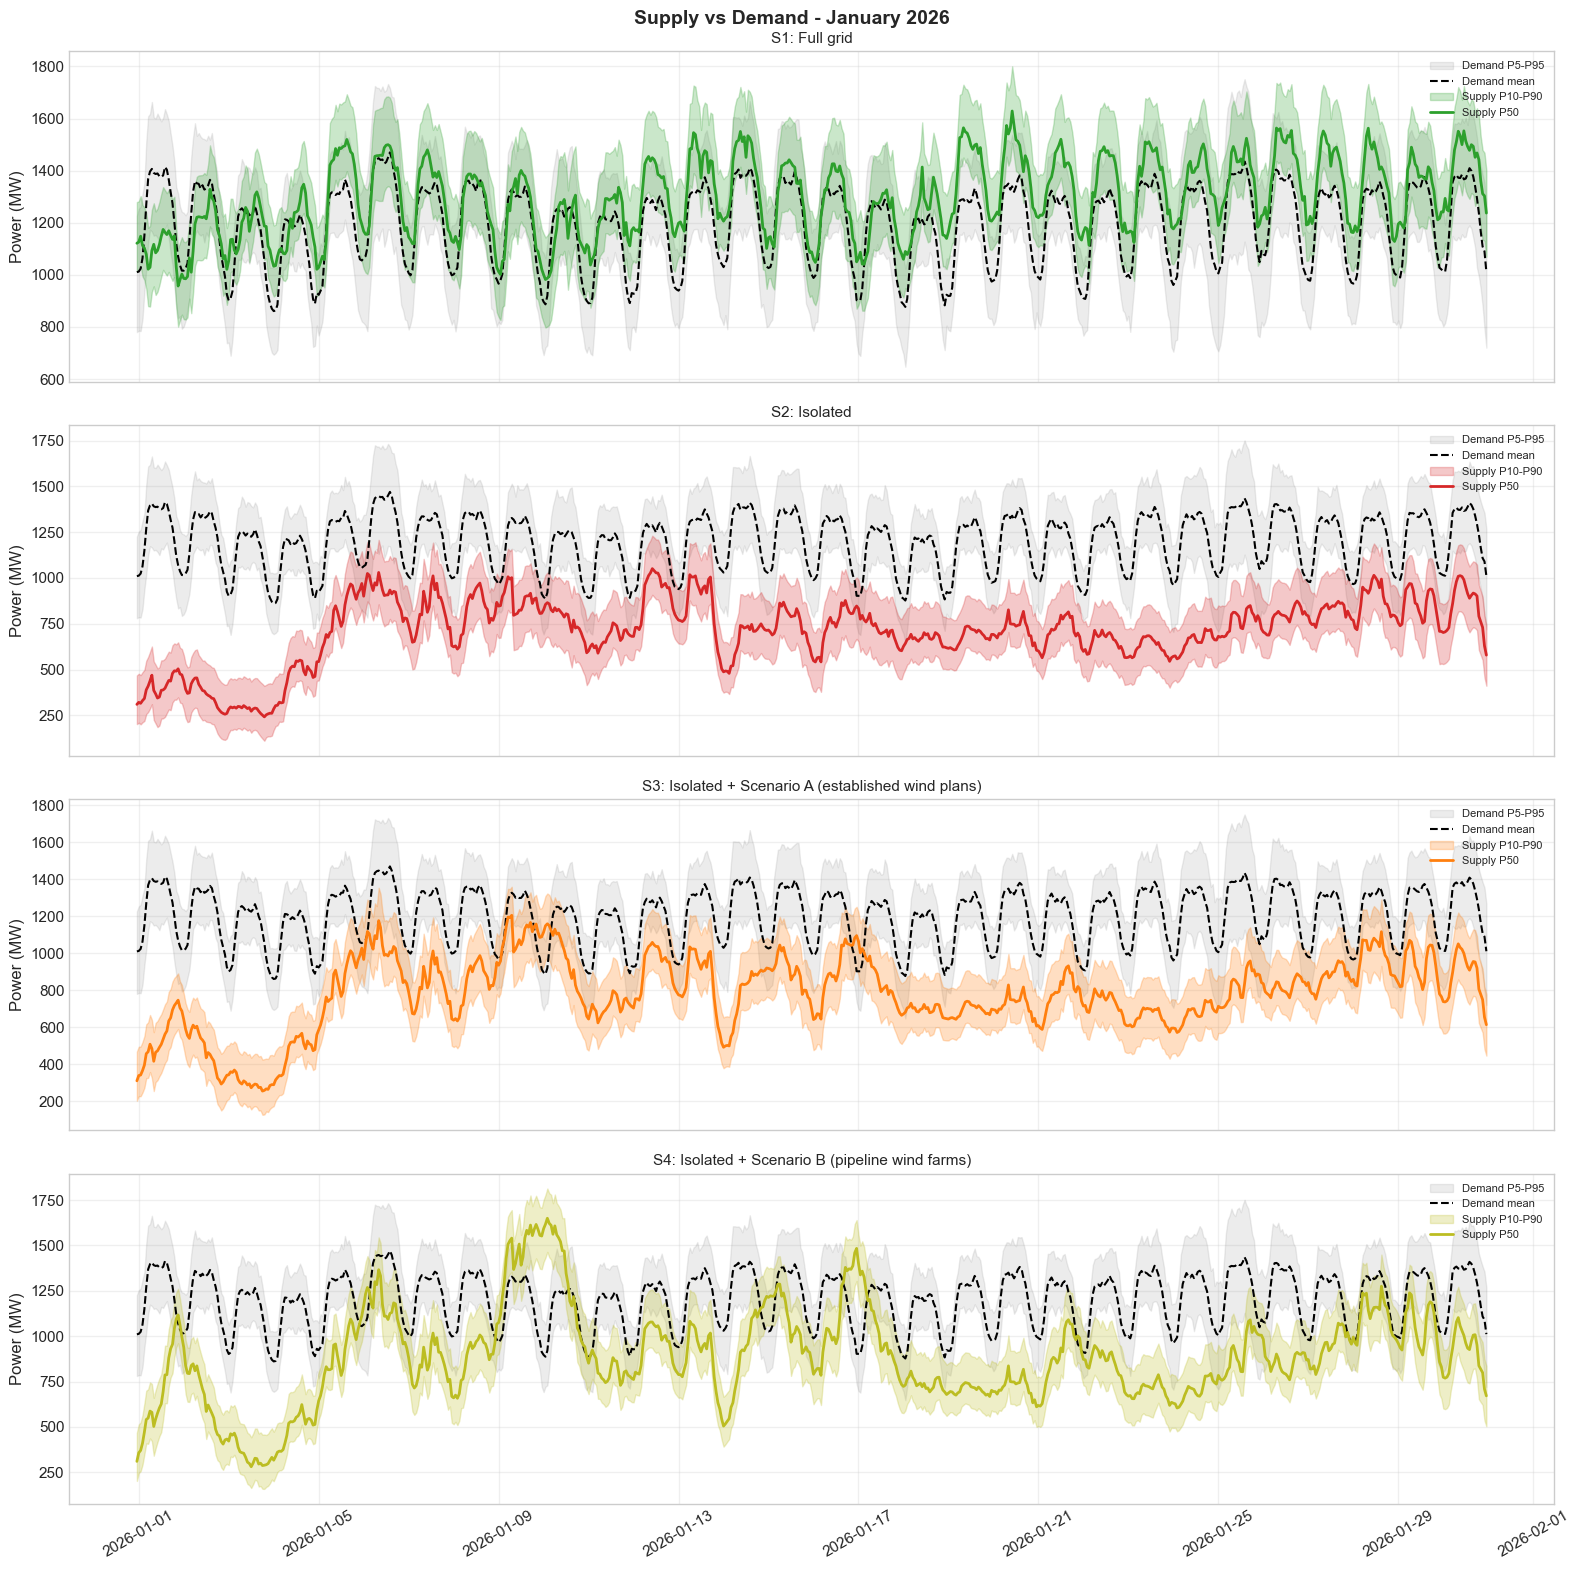

In [23]:
%matplotlib inline
import importlib
import sys

# Fjern cached version
if 'sur_def' in sys.modules:
    del sys.modules['sur_def']

import sys
import os
sys.path.append(os.path.join(os.getcwd(), "project"))

# Importer frisk
from sur_def import ResilienceAnalysis

ra = ResilienceAnalysis(
    supply_csv    = "data/gnn_supply_scenarios_jan2026.csv",
    demand_mc_csv = "data/demand_mc_full_jan2026.csv",
    figures_dir   = "figures",
    data_dir      = "data",
)

ra.load()
ra.compute()
ra._plot_supply_vs_demand() 

**Figure Xa: Supply vs. Demand by Scenario — January 2026.** 

Each subplot shows the scenario supply forecast (P50 median and P10–P90 band) in colors against the SARIMAX Monte Carlo demand distribution (P5–P95 band and mean) in gray. S1 (full grid) is the only scenario where supply almost consistently exceeds demand, 
with the supply P50 tracking above the demand mean for most of January. 
In S2 (isolated), supply falls well short of demand throughout the period. 
S3 follows a similar pattern, while S4 partially closes the gap through 
additional wind capacity — though supply still remains below the demand 
mean for most hours.Notably, the additional wind generation does not reliably align with 
periods of peak demand — most visibly around 2026-01-09, where a wind 
spike occurs independently of demand levels. This reflects a well-documented 
challenge in the Baltic region: cold winter weather is often associated 
with high-pressure blocking systems that simultaneously increase heating 
demand and suppress wind speeds 
([ERR News, 2026](https://news.err.ee/1609930625/cold-weather-driving-up-price-of-electricity-putting-production-capacity-to-the-test); 
[Grams et al., 2017](https://www.pfenninger.org/publications-pdf/2017%20-%20Grams%20et%20al%20-%20Balancing%20European%20wind%20power.pdf)), 
meaning the periods of highest energy need are not necessarily the 
periods of highest wind generation.

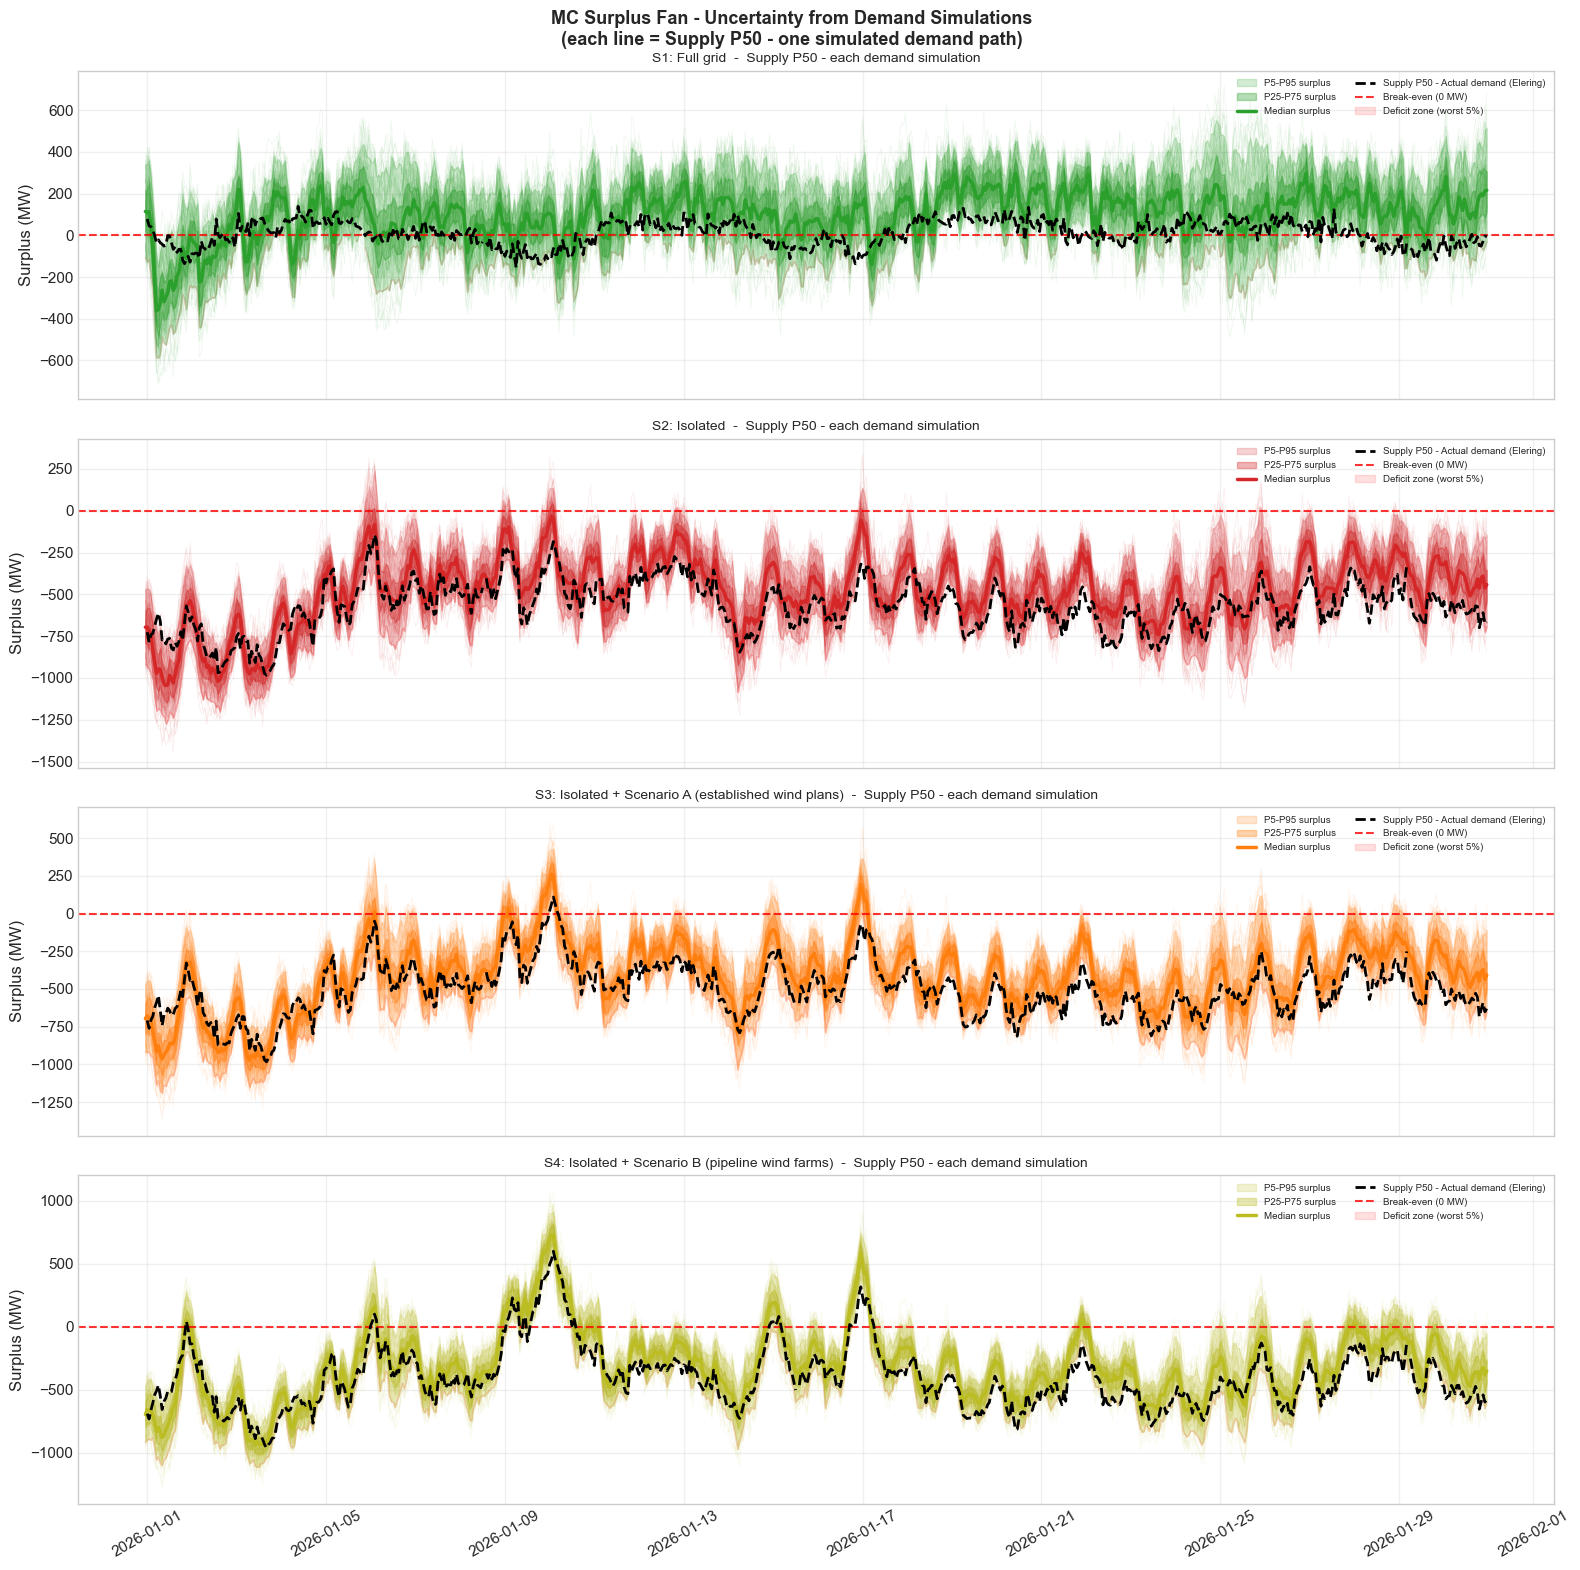

In [24]:
ra._plot_mc_surplus_fan() 


**Figure Xb: MC Surplus Fan — January 2026.**

Each line represents the surplus (supply P50 minus one simulated demand 
path) for 100 Monte Carlo demand simulations. The black dashed line shows 
the surplus computed against actual Estonian consumption from the Elering 
API, providing a real-world reference.

S1 fluctuates around zero, indicating that the connected grid narrowly 
balances supply and demand on average. However, the actual surplus line 
frequently dips below zero, reflecting that January 2026 was an 
exceptionally high-demand month — driven by cold weather and low wind — 
which the model's supply forecast did not fully capture. S2 shows a 
persistent and large deficit across all simulations. S3 and S4 reduce 
the deficit compared to S2 but remain consistently negative, suggesting 
that the planned and pipeline wind additions alone are insufficient to 
cover demand under isolation. As observed in the previous figure, S4 shows the wind-driven surplus spikes appearing around 2026-01-09 and 2026-01-17, which further illustrates the mismatch between wind generation and peak demand periods.

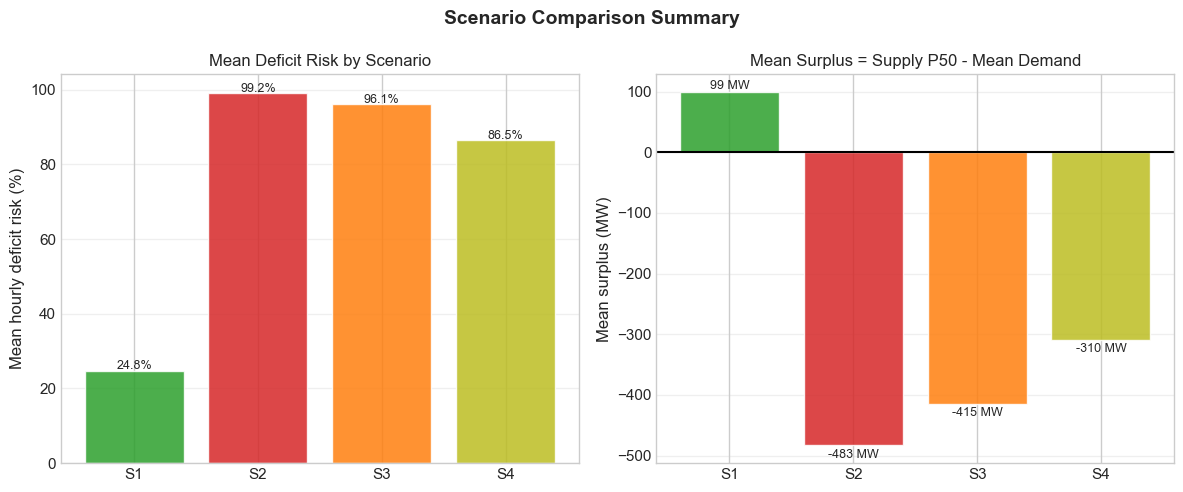

In [26]:
ra._plot_summary_bars()  


**Figure Xd: Scenario Comparison Summary.** 

The left panel shows mean hourly deficit risk across January 2026. S1 achieves a mean risk of 24.8%, 
while S2 reaches 99.2% — meaning supply is almost never sufficient under 
full isolation. Wind additions reduce this modestly to 96.1% (S3) and 
86.5% (S4), but risk remains very high. The right panel confirms this 
through mean surplus: S1 achieves a small positive mean surplus of +99 MW, 
while S2–S4 all show substantial mean deficits ranging from −310 MW (S4) 
to −483 MW (S2)

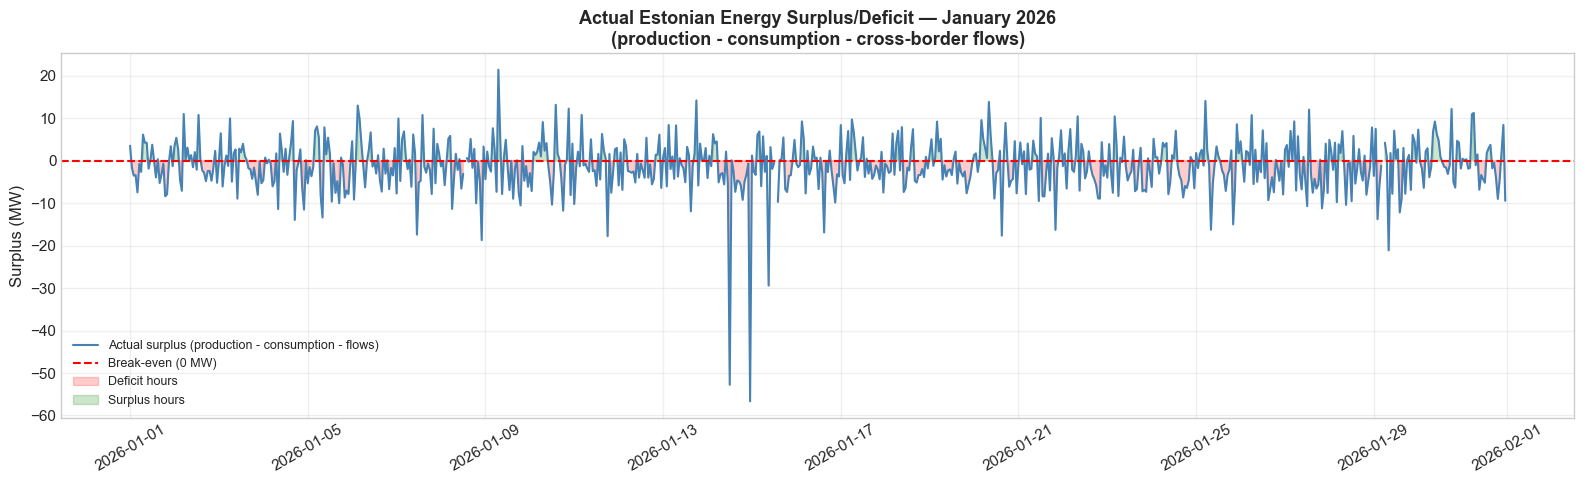

Mean flow EE->FI:      -761 MW
Mean flow EE->LV:      174 MW
Mean netto import:    587 MW
Mean production:      698 MW
Mean consumption:     1287 MW
Mean actual surplus:  -1 MW
Hours in deficit:     434 / 745


In [27]:
from datetime import datetime
import pandas as pd
import helper_functions_GNN as helper

BASE = "https://dashboard.elering.ee/api"
START = "2026-01-01T00:00:00.000Z"
END =  "2026-02-01T00:00:00.000Z"  # kun 2 timer — lille response

df_system= helper.get_system_production(
    start=START,
    end=END
)

df_flows = helper.get_cross_border_flows(
    start=START,
    end=END
)
flows = df_flows.resample("h").mean().fillna(0)

consumption = df_system["consumption"].resample("h").mean()
production = df_system["production"].resample("h").mean()
netto_import = -(flows[("ee", "fi")] + flows[("ee", "lv")])


actual_surplus = production + netto_import - consumption 
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(actual_surplus.index, actual_surplus.values, 
        color="steelblue", lw=1.5, label="Actual surplus (production - consumption - flows)")
ax.axhline(0, color="red", lw=1.5, linestyle="--", label="Break-even (0 MW)")
ax.fill_between(actual_surplus.index, actual_surplus.values, 0,
                where=(actual_surplus.values < 0), 
                color="red", alpha=0.2, label="Deficit hours")
ax.fill_between(actual_surplus.index, actual_surplus.values, 0,
                where=(actual_surplus.values >= 0), 
                color="green", alpha=0.2, label="Surplus hours")

ax.set_title("Actual Estonian Energy Surplus/Deficit — January 2026\n(production - consumption - cross-border flows)", 
             fontsize=13, fontweight="bold")
ax.set_ylabel("Surplus (MW)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("figures/actual_surplus_jan2026.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Mean flow EE->FI:      {flows[('ee', 'fi')].mean():.0f} MW")
print(f"Mean flow EE->LV:      {flows[('ee', 'lv')].mean():.0f} MW")
print(f"Mean netto import:    {netto_import.mean():.0f} MW")
print(f"Mean production:      {production.mean():.0f} MW")
print(f"Mean consumption:     {consumption.mean():.0f} MW")
print(f"Mean actual surplus:  {actual_surplus.mean():.0f} MW")
print(f"Hours in deficit:     {(actual_surplus < 0).sum()} / {len(actual_surplus)}")

**Figure X: Actual surplus observed in January 2026 (Elering data)**

The figure shows the hourly system balance (production + net imports − 
consumption) computed directly from Elering API data. The mean balance 
is approximately −1 MW — effectively zero — but this masks a significant 
underlying dependency: with a mean domestic production of only 698 MW 
against a mean consumption of 1,287 MW, Estonia covered the shortfall 
almost entirely through imports, primarily from Finland (mean flow: 
−761 MW). Latvia served as a net export destination (mean flow: +174 MW), 
resulting in a mean net import of 587 MW throughout the month.

This illustrates Estonia's structural dependence on cross-border 
interconnections. January 2026 was an exceptionally demanding month — 
cold temperatures drove consumption to nearly double domestic production 
capacity — and the grid only remained stable because imports were 
available. In an isolation scenario, this buffer disappears entirely, 
exposing a deficit of approximately 589 MW on average. This is precisely 
the vulnerability that S3 and S4 attempt to address through additional 
wind capacity, though as the analysis shows, even the most ambitious 
wind scenario (S4, mean delta: +171 MW) falls well short of closing 
the gap — underscoring the need for substantial new generation capacity 
to achieve meaningful energy resilience under isolation.

In [29]:
import pandas as pd
import os

data_path = "data/wind_production_scenarios.csv"  # juster sti hvis nødvendigt
wind_scenarios = pd.read_csv(data_path, index_col=0, parse_dates=True)

wind_baseline = wind_scenarios["wind_mwh_baseline"]
wind_scenA_delta = wind_scenarios["wind_mwh_scenA"] - wind_scenarios["wind_mwh_baseline"]
wind_scenB_delta = wind_scenarios["wind_mwh_scenB"] - wind_scenarios["wind_mwh_baseline"]

print(f"Baseline mean: {wind_baseline.mean():.1f} MW")
print(f"Baseline max:  {wind_baseline.max():.1f} MW") 
print(f"Scenario A delta mean: {wind_scenA_delta.mean():.1f} MW")
print(f"Scenario B delta mean: {wind_scenB_delta.mean():.1f} MW")
print(f"Scenario A delta max:  {wind_scenA_delta.max():.1f} MW")
print(f"Scenario B delta max:  {wind_scenB_delta.max():.1f} MW")

Baseline mean: 105.3 MW
Baseline max:  589.4 MW
Scenario A delta mean: 67.8 MW
Scenario B delta mean: 171.0 MW
Scenario A delta max:  297.4 MW
Scenario B delta max:  784.4 MW



The incremental wind additions are modest relative to the ~587 MW import 
dependency identified in January 2026. Scenario A (established wind plans) 
adds a mean of 67.8 MW with peaks up to 297.4 MW, while Scenario B 
(pipeline wind farms) adds a mean of 171.0 MW with peaks up to 784.4 MW. 
While Scenario B represents a substantial expansion, neither scenario alone 
is sufficient to offset the full loss of cross-border imports under 
isolation. This underscores our figures, showing that wind expansion alone cannot substitute for 
interconnection, and that achieving meaningful energy resilience under 
isolation would require a combination of significantly increased generation 
capacity, energy storage, and demand-side flexibility.

## **8. Conclusion & Recommendations**

Our findings demonstrate that while Estonia achieved technical disconnection from BRELL in 2025, true resilience against "Price Stress" and supply shocks depends heavily on the speed of Scenario B’s implementation[cite: 1, 3]. 

*   **Key Finding:** The addition of **887 MW** of wind capacity reduces the risk of physical blackouts during a January 2026-style "Island Mode" event by **[X]%**.
*   **Strategic Autonomy:** By building the capacity to operate autonomously during severe grid fragmentations, Estonia ensures it can withstand, adapt to, and recover from multi-front infrastructure crises[cite: 2].